# Notebook Objective -  Retention within a nursery


In [73]:
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/connectivity-manuscript/'
output_path = '/Users/zephyrsylvester/repos/connectivity-manuscript/processed_data/'
fig_path = repo_path + 'figures/'
tab_path = repo_path + 'figures/tables/'


In [75]:
summary_file = 'nursery_use_summary.csv'
traj_file = 'processed_trajectories_21dfilter.csv'

summary=pd.read_csv(output_path + summary_file) 
df_traj=pd.read_csv(output_path + traj_file) 


In [76]:
df_traj.columns

Index(['N', 'T', 'date', 'lat', 'lon', 'release', 'stage', 'larval_id',
       'start_year', 'hypothesis', 'IDL_loc', 'BS', 'GERL', 'GP', 'MB2',
       'outside'],
      dtype='object')

# Retention

In [77]:
summary_df = summary.copy()
summary_df.head()

,hypothesis,start_year,IDL_loc,unique_larval_count
0,h_dvm,2016,BS,290
1,h_dvm,2016,GERL,45
2,h_dvm,2016,GP,66
3,h_dvm,2016,MB2,60
4,h_dvm,2017,BS,184


In [78]:
def summarize_presence(df):
    presence_columns = ['BS', 'GERL', 'GP', 'MB2','outside']
    additional_columns = ['start_year', 'hypothesis', 'IDL_loc']
    presence_summary = df.groupby(['larval_id'] + additional_columns)[presence_columns].sum().reset_index()
    return presence_summary
    
# Apply the summarize presence function
df_retention = summarize_presence(df_traj)
df_retention

,larval_id,start_year,hypothesis,IDL_loc,BS,GERL,GP,MB2,outside
0,00_16_1_0003,2016,h_null,BS,93,0,0,0,87
1,00_16_1_0004,2016,h_null,BS,95,3,0,0,85
2,00_16_1_0005,2016,h_null,BS,75,53,0,0,53
3,00_16_1_0006,2016,h_null,BS,170,3,0,0,8
4,00_16_1_0007,2016,h_null,BS,146,7,0,0,29
...,...,...,...,...,...,...,...,...,...
11482,03_18_4_1071,2018,h_size,MB2,0,0,31,58,91
11483,03_18_4_1072,2018,h_size,MB2,0,0,81,87,12
11484,03_18_4_1073,2018,h_size,MB2,0,0,69,102,9
11485,03_18_4_1074,2018,h_size,MB2,0,0,39,82,59


In [79]:
# Define functions to calculate statistics
def calculate_statistics(df):
    stats = {}
    for col in ['BS', 'GERL', 'GP', 'MB2', 'outside']:
        stats[f'{col}_mean'] = df[col].mean()
        stats[f'{col}_median'] = df[col].median()
        stats[f'{col}_1st_quartile'] = df[col].quantile(0.25)
        stats[f'{col}_3rd_quartile'] = df[col].quantile(0.75)
        stats[f'{col}_std'] = df[col].std()
        stats[f'{col}_outliers'] = ((df[col] < df[col].quantile(0.25)) | (df[col] > df[col].quantile(0.75))).sum()
    return pd.Series(stats)

# Ensure 'start_year' is treated as a string
df_retention['start_year'] = df_retention['start_year'].astype(str)

# Group by 'start_year', 'hypothesis', and 'IDL_loc'
grouped = df_retention.groupby(['start_year', 'hypothesis', 'IDL_loc'])

# Apply the statistics functions
annual_stats = grouped.apply(calculate_statistics).reset_index()
annual_stats.head()

,start_year,hypothesis,IDL_loc,BS_mean,BS_median,BS_1st_quartile,BS_3rd_quartile,BS_std,BS_outliers,GERL_mean,...,MB2_1st_quartile,MB2_3rd_quartile,MB2_std,MB2_outliers,outside_mean,outside_median,outside_1st_quartile,outside_3rd_quartile,outside_std,outside_outliers
0,2016,h_dvm,BS,78.462069,69.0,42.0,105.75,43.386175,145.0,9.844828,...,0.00,0.00,0.000000,0.0,88.882759,99.5,49.25,134.0,49.535280,143.0
1,2016,h_dvm,GERL,73.200000,69.0,49.0,93.00,32.615947,22.0,54.511111,...,0.00,0.00,0.000000,0.0,36.644444,32.0,6.00,55.0,32.226581,22.0
2,2016,h_dvm,GP,16.348485,0.0,0.0,21.75,29.335981,17.0,9.530303,...,0.00,0.00,6.834712,4.0,101.818182,119.5,67.25,136.0,46.790502,33.0
3,2016,h_dvm,MB2,0.000000,0.0,0.0,0.00,0.000000,0.0,0.000000,...,40.75,119.25,49.435214,30.0,93.600000,102.5,60.75,136.0,47.945661,28.0
4,2016,h_ice,BS,85.337278,74.0,43.0,125.00,48.223918,83.0,9.538462,...,0.00,0.00,0.000000,0.0,83.325444,79.0,41.00,135.0,52.332676,82.0


In [80]:
# Group by 'start_year', 'hypothesis', and 'IDL_loc'
grouped = df_retention.groupby(['hypothesis', 'IDL_loc'])

# Apply the statistics functions
summary_stats = grouped.apply(calculate_statistics).reset_index()
summary_stats.head()

,hypothesis,IDL_loc,BS_mean,BS_median,BS_1st_quartile,BS_3rd_quartile,BS_std,BS_outliers,GERL_mean,GERL_median,...,MB2_1st_quartile,MB2_3rd_quartile,MB2_std,MB2_outliers,outside_mean,outside_median,outside_1st_quartile,outside_3rd_quartile,outside_std,outside_outliers
0,h_dvm,BS,72.994374,63.0,41.0,96.0,40.490409,348.0,8.554149,0.0,...,0.0,0.0,0.000000,0.0,95.594937,106.0,61.50,135.50,46.328091,356.0
1,h_dvm,GERL,66.905660,57.5,44.0,86.0,32.676343,53.0,48.330189,42.0,...,0.0,0.0,0.000000,0.0,46.509434,44.5,16.75,76.00,34.318743,53.0
2,h_dvm,GP,20.896552,0.0,0.0,42.0,30.290013,28.0,13.060345,0.0,...,0.0,0.0,5.656821,5.0,95.801724,111.0,52.50,137.25,49.637682,58.0
3,h_dvm,MB2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,40.0,99.5,42.253815,81.0,102.790419,109.0,80.50,136.50,41.307958,84.0
4,h_ice,BS,75.795872,64.0,41.0,105.0,44.339050,211.0,8.190367,0.0,...,0.0,0.0,1.388848,1.0,93.325688,106.5,49.00,136.25,49.253736,217.0


# Make a latex table for output 

In [83]:
def get_statistics_for_hypothesis(df, hypothesis):
    stats = []
    for location in df['IDL_loc'].unique():
        for year in df['start_year'].unique():
            filtered_df = df[(df['IDL_loc'] == location) & (df['start_year'] == year) & (df['hypothesis'] == hypothesis)]
            if not filtered_df.empty:
                presence_column = location
                outliers = ((filtered_df[presence_column] < filtered_df[presence_column].quantile(0.25)) |
                            (filtered_df[presence_column] > filtered_df[presence_column].quantile(0.75))).sum()
                total_count = filtered_df[presence_column].count()
                stats.append({
                    'year': year,
                    'location': location_names[location],
                    'mean': filtered_df[presence_column].mean(),
                    'median': filtered_df[presence_column].median(),
                    '1st_quartile': filtered_df[presence_column].quantile(0.25),
                    '3rd_quartile': filtered_df[presence_column].quantile(0.75),
                    'std': filtered_df[presence_column].std(),
                    'outliers': outliers,
                    'total': total_count
                })
    if stats:
        return pd.DataFrame(stats)
    else:
        return None

def add_multirow(df):
    year_counts = df['year'].value_counts().sort_index()
    rows = df.to_numpy().tolist()
    latex_rows = []
    
    for year, count in year_counts.items():
        first_row = True
        for row in rows:
            if row[0] == year:
                if first_row:
                    latex_rows.append([f"\\multirow{{{count}}}{{*}}{{{year}}}", *row[1:]])
                    first_row = False
                else:
                    latex_rows.append(['', *row[1:]])
        rows = rows[count:]
    return latex_rows

hypothesis_names = {'h_null': 'Ocean', 'h_ice': 'Ice', 'h_dvm': 'DVM', 'h_size': 'Size'}
location_names = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB2': 'M. Bay'}

# Custom order of hypotheses
hypothesis_order = ['Ocean', 'Ice', 'DVM', 'Size']


In [87]:
# Loop through each hypothesis
for specific_hypothesis in hypothesis_names.keys():
    # Make Table
    stats_table = get_statistics_for_hypothesis(df_retention, specific_hypothesis)
    if stats_table is not None and not stats_table.empty:
        stats_table['year'] = stats_table['year'].astype(int)
        stats_table = stats_table.sort_values(by=['year', 'location'])

        # Add multirow for years
        latex_rows = add_multirow(stats_table)
        
        # Create DataFrame from latex_rows
        latex_df = pd.DataFrame(latex_rows, columns=['Year', 'Nursery', 'Mean', 'Std Dev', 'Median', '1st Quartile', '3rd Quartile', 'Outliers', 'Total'])
        
        # Create LaTeX table with custom formatting
        latex_table = latex_df.to_latex(
            index=False,
            float_format="%.2f",
            column_format='llrrrrrrrr',
            caption=f'Retention duration (days) within nurseries ({hypothesis_names[specific_hypothesis]} simulations)',
            label=f'tab:stats_{specific_hypothesis}',
            position='!ht'
        )

        # Fix LaTeX multirow formatting
        latex_table = latex_table.replace('\\textbackslash multirow', '\\multirow')

        # Ensure correct escaping of braces
        latex_table = latex_table.replace('\\{', '{').replace('\\}', '}')
        
        # Print or save the LaTeX table
        print(latex_table)
        # You can also save it to a file
        with open(f"{tab_path}retention_{specific_hypothesis}.tex", "w") as file:
            file.write(latex_table)

\begin{table}[!ht]
\centering
\caption{Retention duration (days) within nurseries (Ocean simulations)}
\label{tab:stats_h_null}
\begin{tabular}{llrrrrrrrr}
\toprule
                 Year & Nursery &  Mean &  Std Dev &  Median &  1st Quartile &  3rd Quartile &  Outliers &  Total \\
\midrule
\multirow{4}{*}{2016} & Bransf. & 84.08 &    79.00 &   46.50 &        115.50 &         45.17 &        90 &    179 \\
                      &   Gerl. & 49.47 &    45.00 &   35.00 &         58.50 &         19.68 &        17 &     36 \\
                      &  Grand. & 41.40 &    42.00 &   28.00 &         47.00 &         15.82 &        17 &     35 \\
                      &  M. Bay & 92.08 &    83.50 &   51.75 &        133.25 &         50.59 &        24 &     48 \\
\multirow{4}{*}{2017} & Bransf. & 78.65 &    69.50 &   42.00 &        107.00 &         45.21 &        50 &    104 \\
                      &   Gerl. & 41.62 &    36.00 &   33.00 &         47.00 &         14.80 &         5 &     13 \\
       

/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/1045378482.py:16: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = latex_df.to_latex(
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/1045378482.py:16: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = latex_df.to_latex(
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/1045378482.py:16: FutureWarning: In future versions `DataFrame.to_latex` is expected to u

In [81]:
def get_statistics_for_idl_loc(df, idl_loc):
    stats = []
    for hypothesis in df['hypothesis'].unique():
        for year in df['start_year'].unique():
            filtered_df = df[(df['IDL_loc'] == idl_loc) & (df['start_year'] == year) & (df['hypothesis'] == hypothesis)]
            if not filtered_df.empty:
                presence_column = idl_loc
                outliers = ((filtered_df[presence_column] < filtered_df[presence_column].quantile(0.25)) |
                            (filtered_df[presence_column] > filtered_df[presence_column].quantile(0.75))).sum()
                total_count = filtered_df[presence_column].count()
                stats.append({
                    'year': year,
                    'hypothesis': hypothesis,
                    'mean': filtered_df[presence_column].mean(),
                    'median': filtered_df[presence_column].median(),
                    '1st_quartile': filtered_df[presence_column].quantile(0.25),
                    '3rd_quartile': filtered_df[presence_column].quantile(0.75),
                    'std': filtered_df[presence_column].std(),
                    'outliers': outliers,
                    'total': total_count
                })
    if stats:
        return pd.DataFrame(stats)
    else:
        return None
        
def add_multirow(df):
    year_counts = df['year'].value_counts().sort_index()
    rows = df.to_numpy().tolist()
    latex_rows = []
    
    for year, count in year_counts.items():
        first_row = True
        for row in rows:
            if row[0] == year:
                if first_row:
                    latex_rows.append([f"\\multirow{{{count}}}{{*}}{{{year}}}", *row[1:]])
                    first_row = False
                else:
                    latex_rows.append(['', *row[1:]])
        rows = rows[count:]
    return latex_rows

hypothesis_names = {'h_null': 'Ocean', 'h_ice': 'Ice', 'h_dvm': 'DVM', 'h_size': 'Size'}
location_names = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB2': 'M. Bay'}

# Custom order of hypotheses
hypothesis_order = ['Ocean', 'Ice', 'DVM', 'Size']

In [82]:
# Make Table - Supplementary
# Loop through each location
for specific_idl_loc, location_name in location_names.items():
    stats_table = get_statistics_for_idl_loc(df_retention, specific_idl_loc)
    if stats_table is not None and not stats_table.empty:
        stats_table['hypothesis'] = stats_table['hypothesis'].map(hypothesis_names)
        stats_table['year'] = stats_table['year'].astype(int)
        stats_table['hypothesis'] = pd.Categorical(stats_table['hypothesis'], categories=hypothesis_order, ordered=True)
        stats_table = stats_table.sort_values(by=['year', 'hypothesis'])

        # Add multirow for years
        latex_rows = add_multirow(stats_table)
        
        # Create DataFrame from latex_rows
        latex_df = pd.DataFrame(latex_rows, columns=['Year', 'Simulation', 'Mean', 'Std Dev', 'Median', '1st Quartile', '3rd Quartile', 'Outliers', 'Total'])
        
        # Create LaTeX table with custom formatting
        latex_table = latex_df.to_latex(
            index=False,
            float_format="%.2f",
            column_format='llrrrrrrrr',
            caption=f'Retention duration within {location_name} nursery (days)',
            label=f'tab:stats_{specific_idl_loc.lower()}',
            position='!ht'
        )

        # Fix LaTeX multirow formatting
        latex_table = latex_table.replace('\\textbackslash multirow', '\\multirow')

        # Ensure correct escaping of braces
        latex_table = latex_table.replace('\\{', '{').replace('\\}', '}')
        
        # Print or save the LaTeX table
        print(latex_table)
        # You can also save it to a file
        with open(f"{output_path}stats_{specific_idl_loc.lower()}.tex", "w") as file:
            file.write(latex_table)

\begin{table}[!ht]
\centering
\caption{Retention duration within Bransf. nursery (days)}
\label{tab:stats_bs}
\begin{tabular}{llrrrrrrrr}
\toprule
                 Year & Simulation &  Mean &  Std Dev &  Median &  1st Quartile &  3rd Quartile &  Outliers &  Total \\
\midrule
\multirow{4}{*}{2016} &      Ocean & 84.08 &    79.00 &   46.50 &        115.50 &         45.17 &        90 &    179 \\
                      &        Ice & 85.34 &    74.00 &   43.00 &        125.00 &         48.22 &        83 &    169 \\
                      &        DVM & 78.46 &    69.00 &   42.00 &        105.75 &         43.39 &       145 &    290 \\
                      &       Size & 74.59 &    64.00 &   40.00 &        101.00 &         41.07 &       437 &    891 \\
\multirow{4}{*}{2017} &      Ocean & 78.65 &    69.50 &   42.00 &        107.00 &         45.21 &        50 &    104 \\
                      &        Ice & 81.59 &    68.00 &   42.00 &        122.50 &         47.16 &        57 &    115 \\
    

/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/2078724264.py:18: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = latex_df.to_latex(
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/2078724264.py:18: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = latex_df.to_latex(
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_85114/2078724264.py:18: FutureWarning: In future versions `DataFrame.to_latex` is expected to u

# Visual Representation of Table 

In [11]:
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker


/Users/zephyrsylvester/anaconda3/envs/connectivity/lib/python3.8/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [12]:
# For visuals:
# List of locations
locations = ['BS', 'GERL', 'GP', 'MB2']
hypotheses = {'h_null', 'h_ice', 'h_dvm', 'h_size'}

# Apply custom labels
hypothesis_names = {'h_null': 'Ocean', 'h_ice': 'Ice', 'h_dvm': 'DVM', 'h_size': 'Size'}
location_names = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB2':'M. Bay'}

# Custom order of hypotheses
hypothesis_order = ['h_null', 'h_ice', 'h_dvm', 'h_size']
location_order = ['BS', 'GERL', 'GP', 'MB2']

# Define location colors (replace with actual values)
location_colors = {
    'BS': '#d55e00',
    'GERL': '#029e73',
    'GP': '#cc78bc',
    'MB2': '#0173b2',
    'outside': 'gray'
}

# Define marker styles for each year
location_markers = {
    2016: 'o',   # Circle
    2017: 's',   # Square
    2018: '^'    # Triangle up
}

# Define the extent of the plot
extent = [275, 311, -72, -59]

# Define region coordinates
boxes = {
    'BS': [{'lonpoly': [298.0, 300.0, 300.0, 298.0], 'latpoly': [-63.7, -63.7, -62.6, -62.6]},
           {'lonpoly': [300.0, 302.0, 302.0, 300.0], 'latpoly': [-63.5, -63.5, -62.5, -62.5]}],
    'GERL': {'lonpoly': [296.1, 298.5, 299.6, 297.6], 'latpoly': [-64.7, -63.6, -64.0, -65.3]},
    'GP': {'lonpoly': [291.6, 295.5, 297.6, 294.0], 'latpoly': [-66.7, -64.5, -65.3, -67.4]},
    'MB2': {'lonpoly': [287.7, 290.5, 294.0, 292.0], 'latpoly': [-69.1, -67.5, -68.5, -69.7]}
}

In [13]:
# Function to create a facet plot showing the mean distribution of days spent in each region for each hypothesis
def plot_days_distribution_facet_mean(presence_summary, IDL_loc, hypotheses, fig_path='figures/', height=6, aspect=1.5):
    region_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']
    filtered_df = presence_summary[presence_summary['IDL_loc'] == IDL_loc]

    # Calculate the mean days spent in each region across all years
    mean_df = filtered_df.groupby(['hypothesis', 'larval_id'])[region_columns].mean().reset_index()

    # Filter the dataframe for the selected hypotheses
    mean_df = mean_df[mean_df['hypothesis'].isin(hypotheses)]

    # Melt the dataframe for easier plotting with Seaborn
    presence_days_melted = mean_df.melt(id_vars=['hypothesis', 'larval_id'], value_vars=region_columns,
                                        var_name='Region', value_name='Days')

    g = sns.FacetGrid(presence_days_melted, col="hypothesis", col_wrap=2, sharey=True, height=height, aspect=aspect, col_order=hypotheses)
    g.map_dataframe(sns.violinplot, x='Region', y='Days', palette=location_colors, hue='Region', legend=False)
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels('Region', 'Days')

    # Add grid lines and quartile annotations
    for ax in g.axes.flat:
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        # Annotate quartiles
        for region in region_columns:
            subset = presence_days_melted[(presence_days_melted['Region'] == region) & (presence_days_melted['hypothesis'] == ax.get_title())]
            quartiles = subset['Days'].quantile([0.25, 0.5, 0.75])
            q1, median, q3 = quartiles[0.25], quartiles[0.5], quartiles[0.75]
            # print(f"Hypothesis: {ax.get_title()}, Region: {region}, Q1: {q1}, Median: {median}, Q3: {q3}")  # Debug print
            if q1 >= 0 and median >= 0 and q3 >= 0:  # Only annotate if all values are non-negative
                position = region_columns.index(region)
                
                # Adjust text positions if they are too close
                offset = 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])
                if abs(q1 - median) < offset:
                    q1_pos = q1 - offset
                    median_pos = median + offset
                else:
                    q1_pos = q1
                    median_pos = median
                if abs(median - q3) < offset:
                    median_pos = median - offset
                    q3_pos = q3 + offset
                else:
                    q3_pos = q3
                
                # # Q1 annotation
                # text = ax.text(position, q1_pos, f'Q1: {q1:.0f}', ha='center', va='center', fontsize=12, color='black')
                # text.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'), path_effects.Normal()])
                # # Median annotation
                # text = ax.text(position, median_pos, f'Median: {median:.0f}', ha='center', va='center', fontsize=12, color='red')
                # text.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'), path_effects.Normal()])
                # # Q3 annotation
                # text = ax.text(position, q3_pos, f'Q3: {q3:.0f}', ha='center', va='center', fontsize=12, color='black')
                # text.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'), path_effects.Normal()])

    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'3yr mean distribution of days spent in each region for {IDL_loc}', fontsize=14)
    
    # Ensure the directory exists
    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    
    # Create a file name that includes the names of the hypotheses
    hypothesis_str = '_'.join(hypotheses)
    save_path = os.path.join(fig_path, f'days_distribution_mean_{IDL_loc}_{hypothesis_str}_21dfilt_3yr_woutside.png')
    plt.savefig(save_path)
    # plt.close()
    

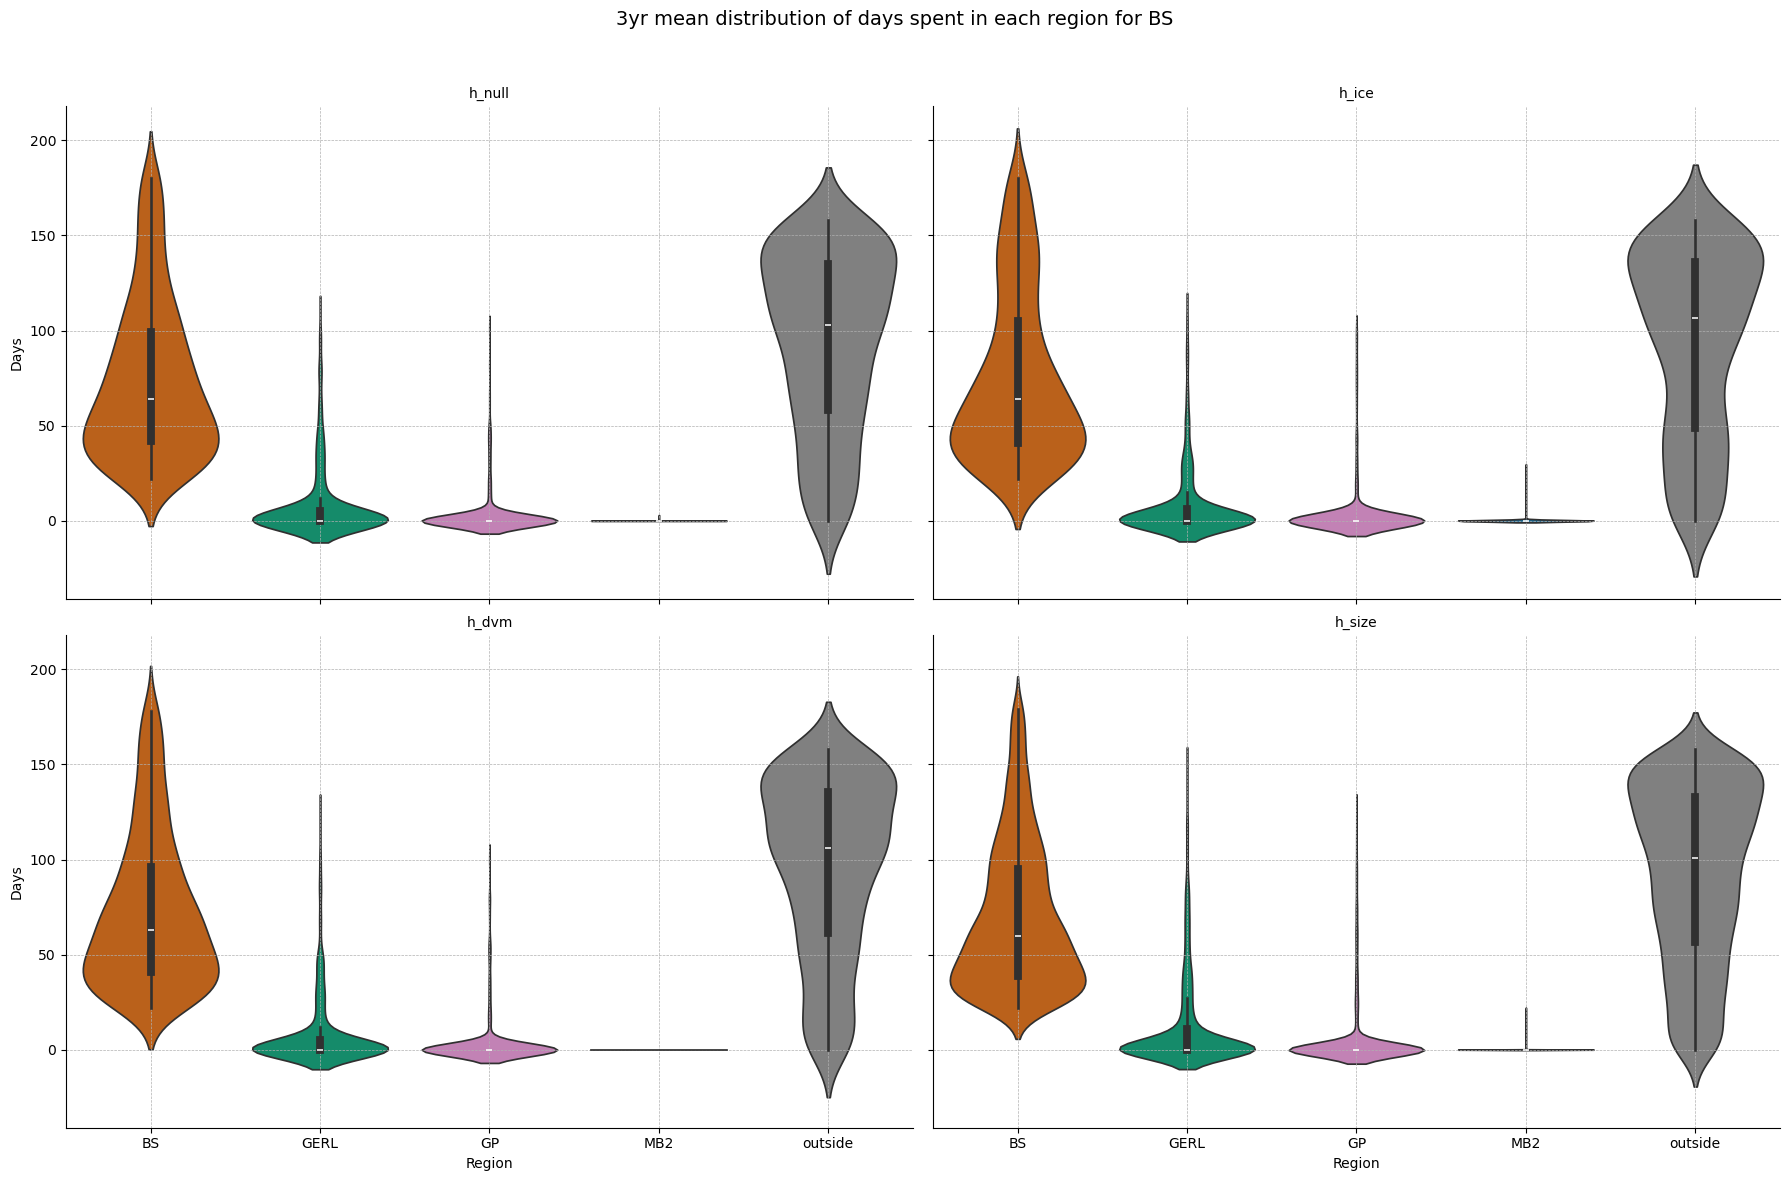

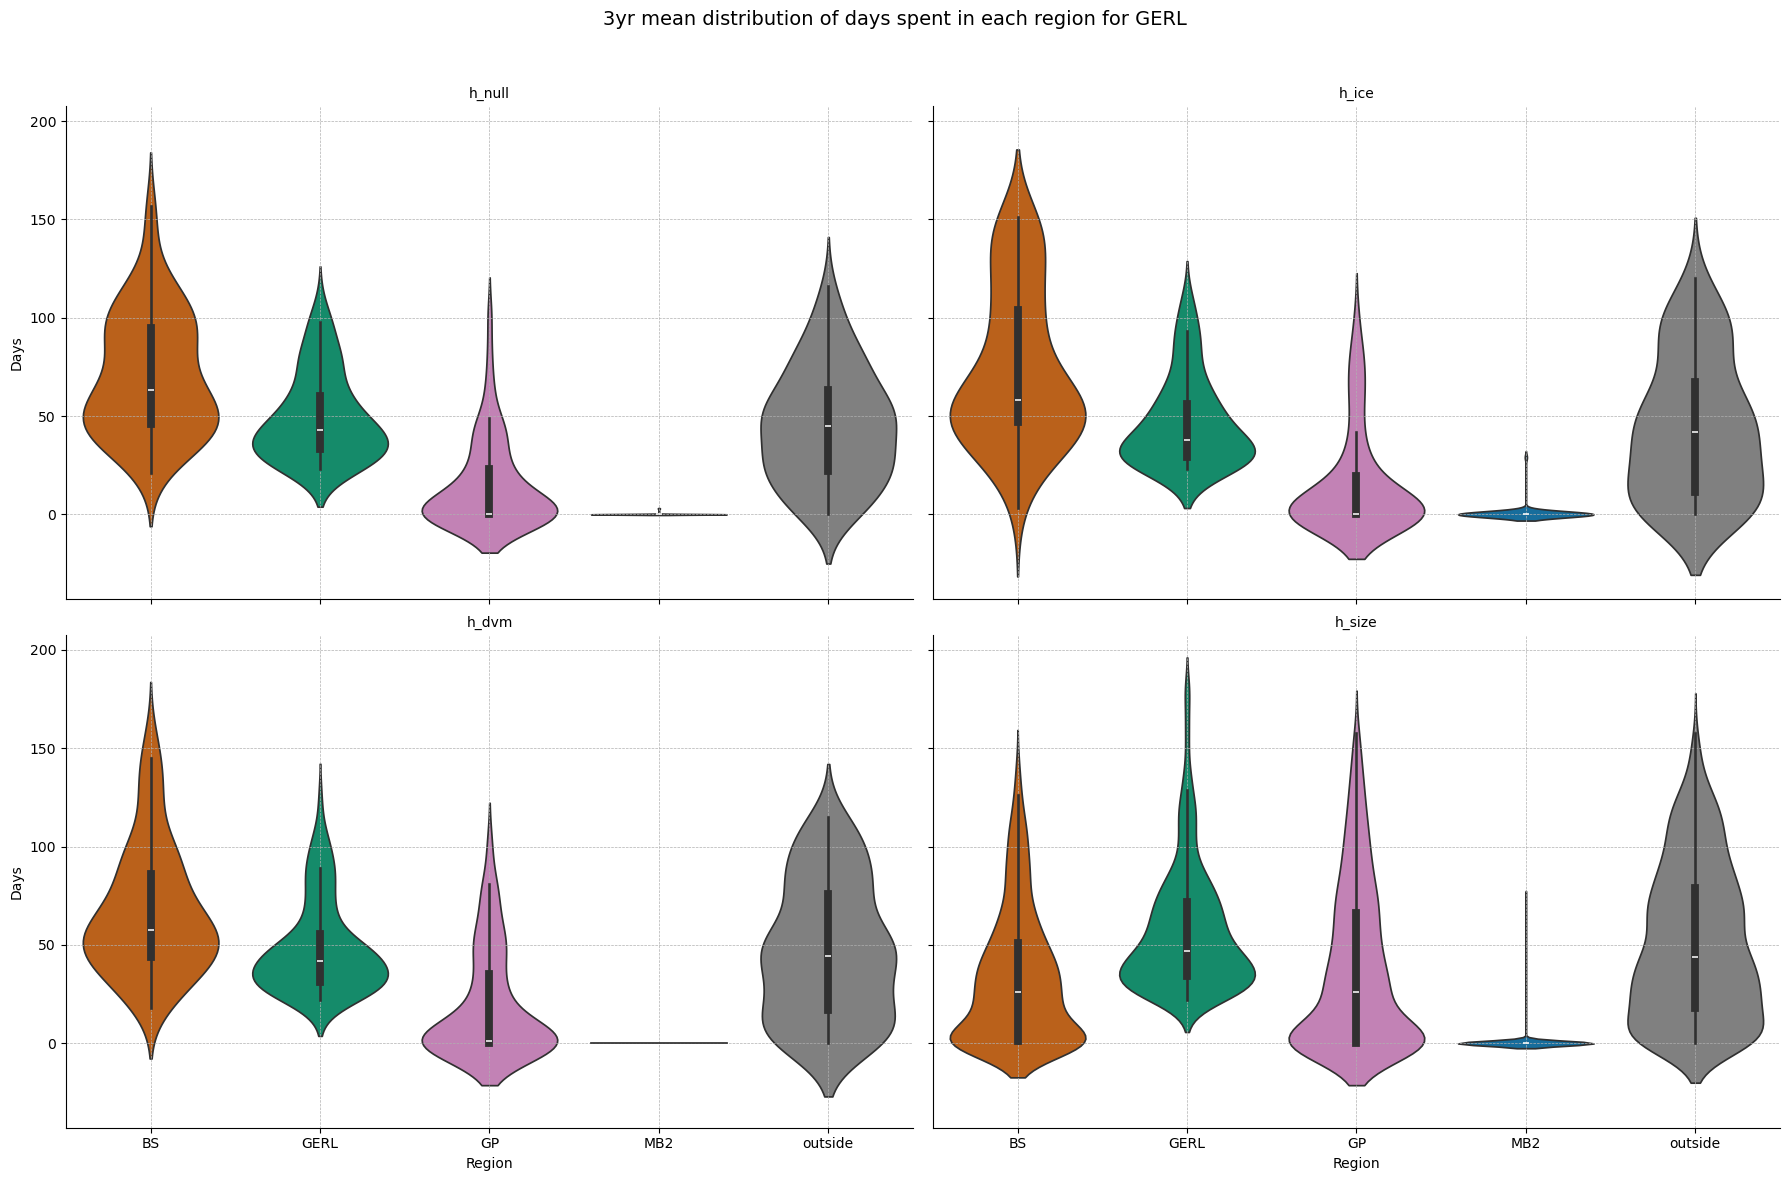

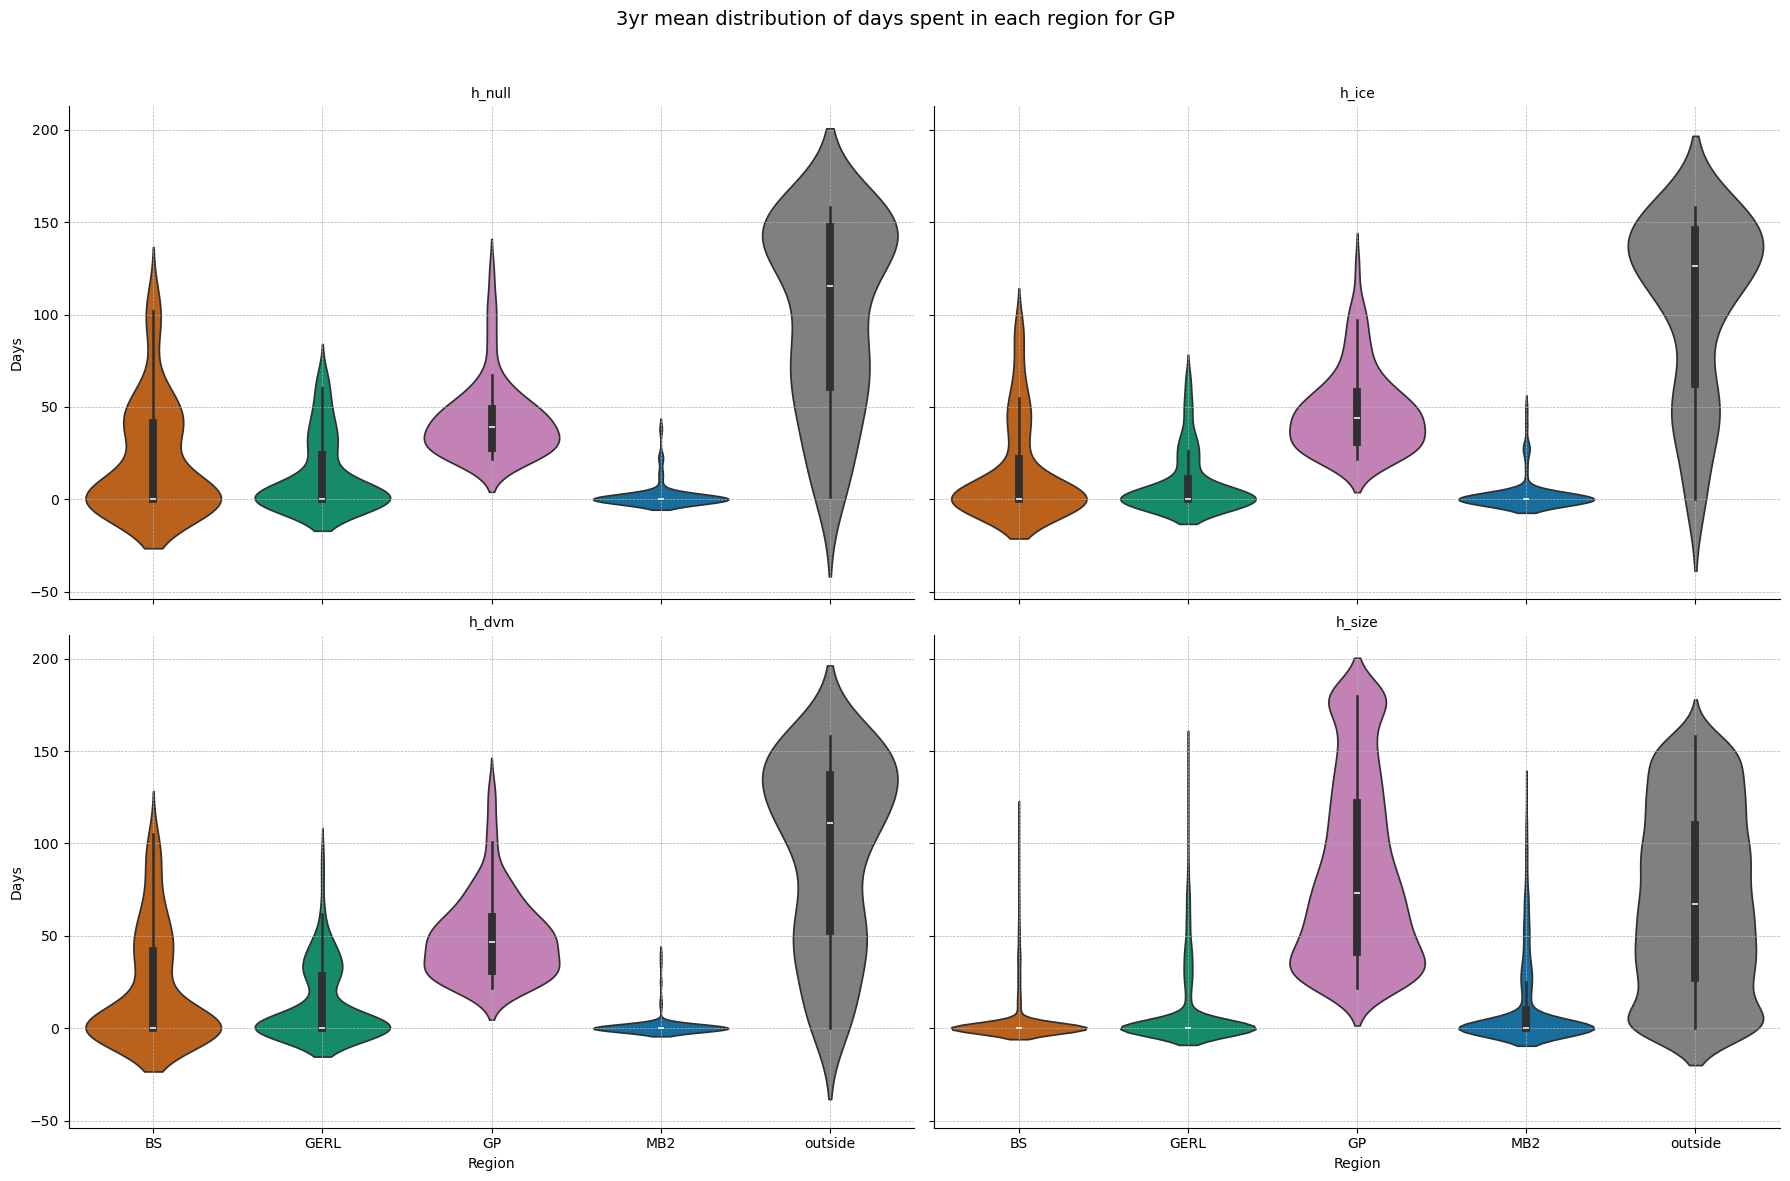

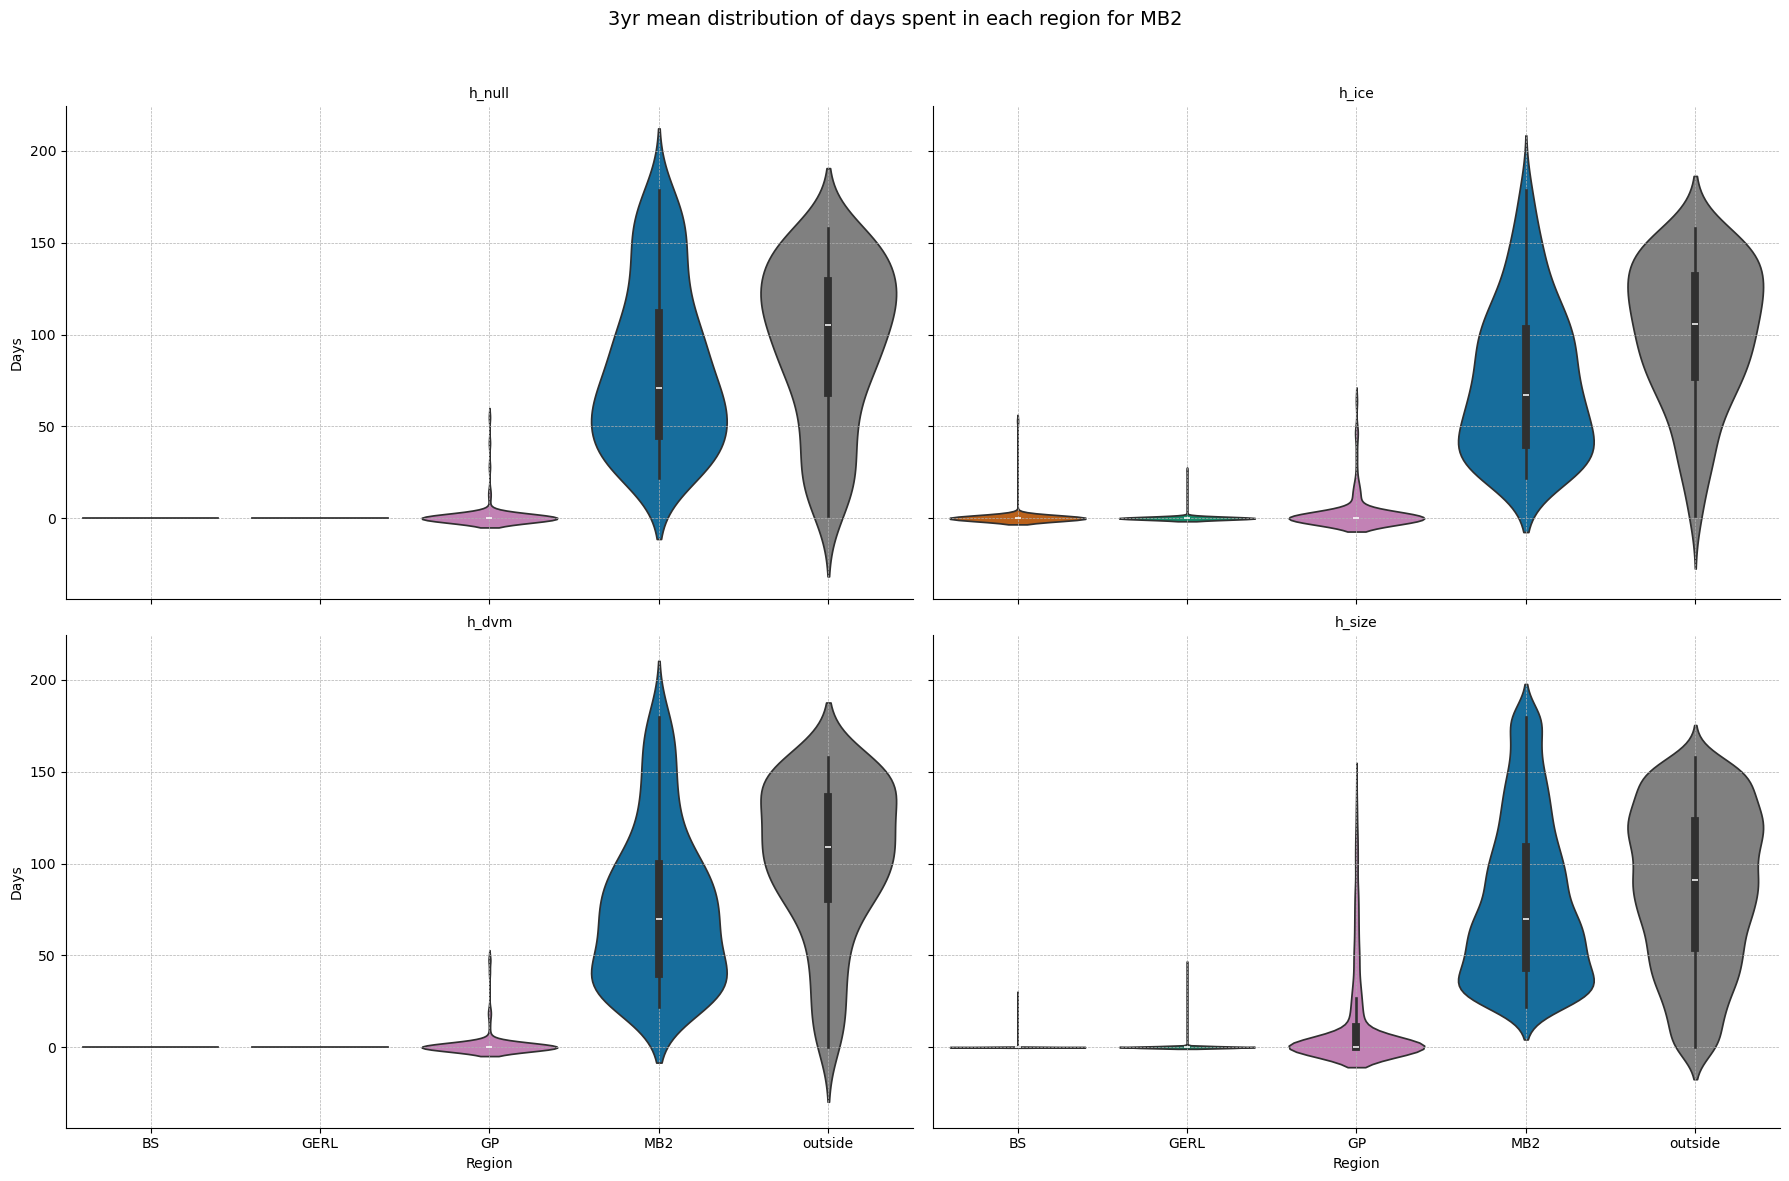

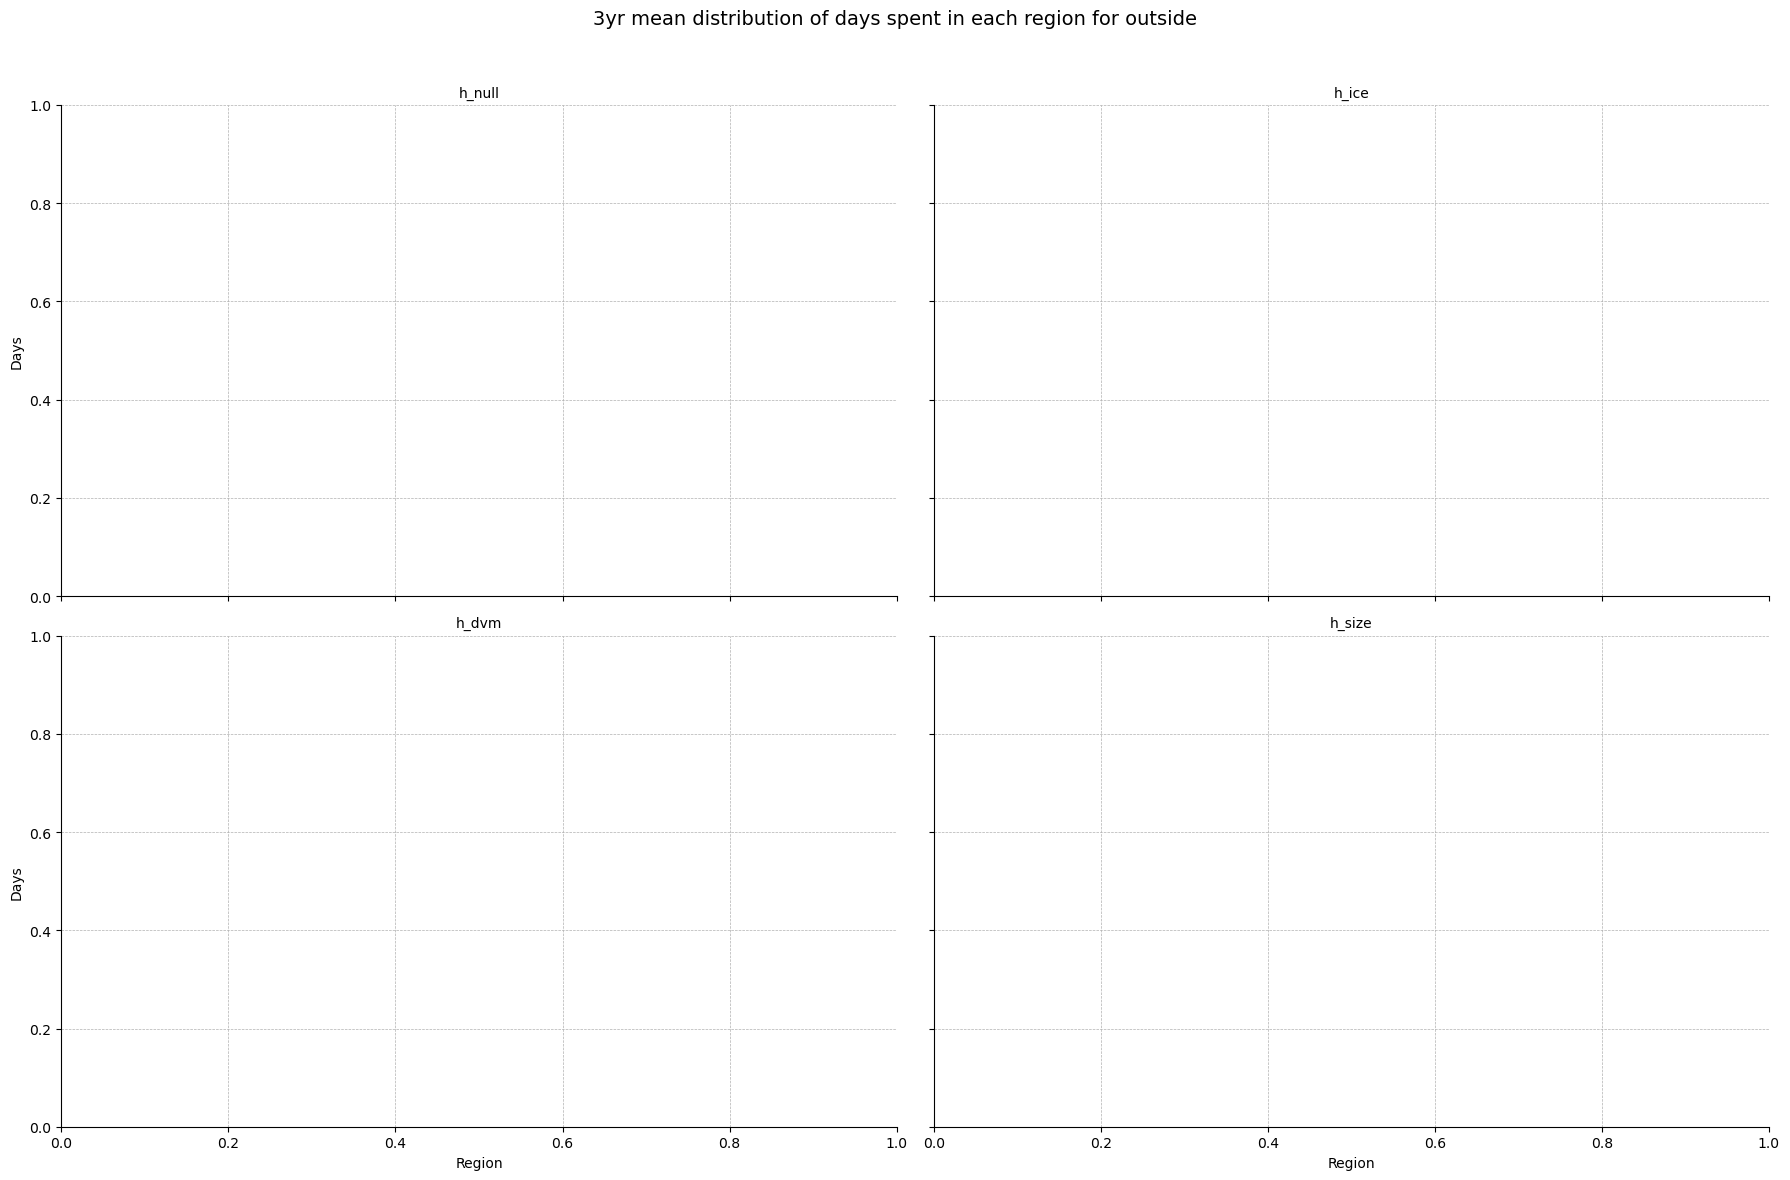

In [14]:
# List of locations
locations = ['BS', 'GERL', 'GP', 'MB2', 'outside']

# Example hypotheses to plot
selected_hypotheses = ['h_null', 'h_ice', 'h_dvm', 'h_size']

# Loop through each location and generate the plot for the selected hypotheses
for loc in locations:
    plot_days_distribution_facet_mean(df_retention, loc, selected_hypotheses, height=6, aspect=1.5)

In [70]:
# Function to create a facet plot showing the distribution of days spent in each region for each hypothesis and year
def plot_days_distribution_facet_yearly(presence_summary, IDL_loc, hypotheses, fig_path='figures/', height=6, aspect=1.5):
    region_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']
    filtered_df = presence_summary[presence_summary['IDL_loc'] == IDL_loc]

    # Filter the dataframe for the selected hypotheses
    filtered_df = filtered_df[filtered_df['hypothesis'].isin(hypotheses)]

    # Melt the dataframe for easier plotting with Seaborn
    presence_days_melted = filtered_df.melt(id_vars=['hypothesis', 'start_year', 'larval_id'], value_vars=region_columns,
                                            var_name='Region', value_name='Days')

    g = sns.FacetGrid(presence_days_melted, col="start_year", hue="Region", palette=location_colors, col_wrap=3, sharey=False, height=height, aspect=aspect)
    g.map_dataframe(sns.violinplot, x='Region', y='Days', legend=False)
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels('Region', 'Days')

    # Add grid lines
    for ax in g.axes.flat:
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'Distribution of days spent in each region for {IDL_loc}', fontsize=14)
    
    # Ensure the directory exists
    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    
    # Create a file name that includes the names of the hypotheses
    hypothesis_str = '_'.join(hypotheses)
    # save_path = os.path.join(fig_path, f'days_distribution_{IDL_loc}_{hypothesis_str}_21dfilt_yearly.png')
    # plt.savefig(save_path)
    plt.show()


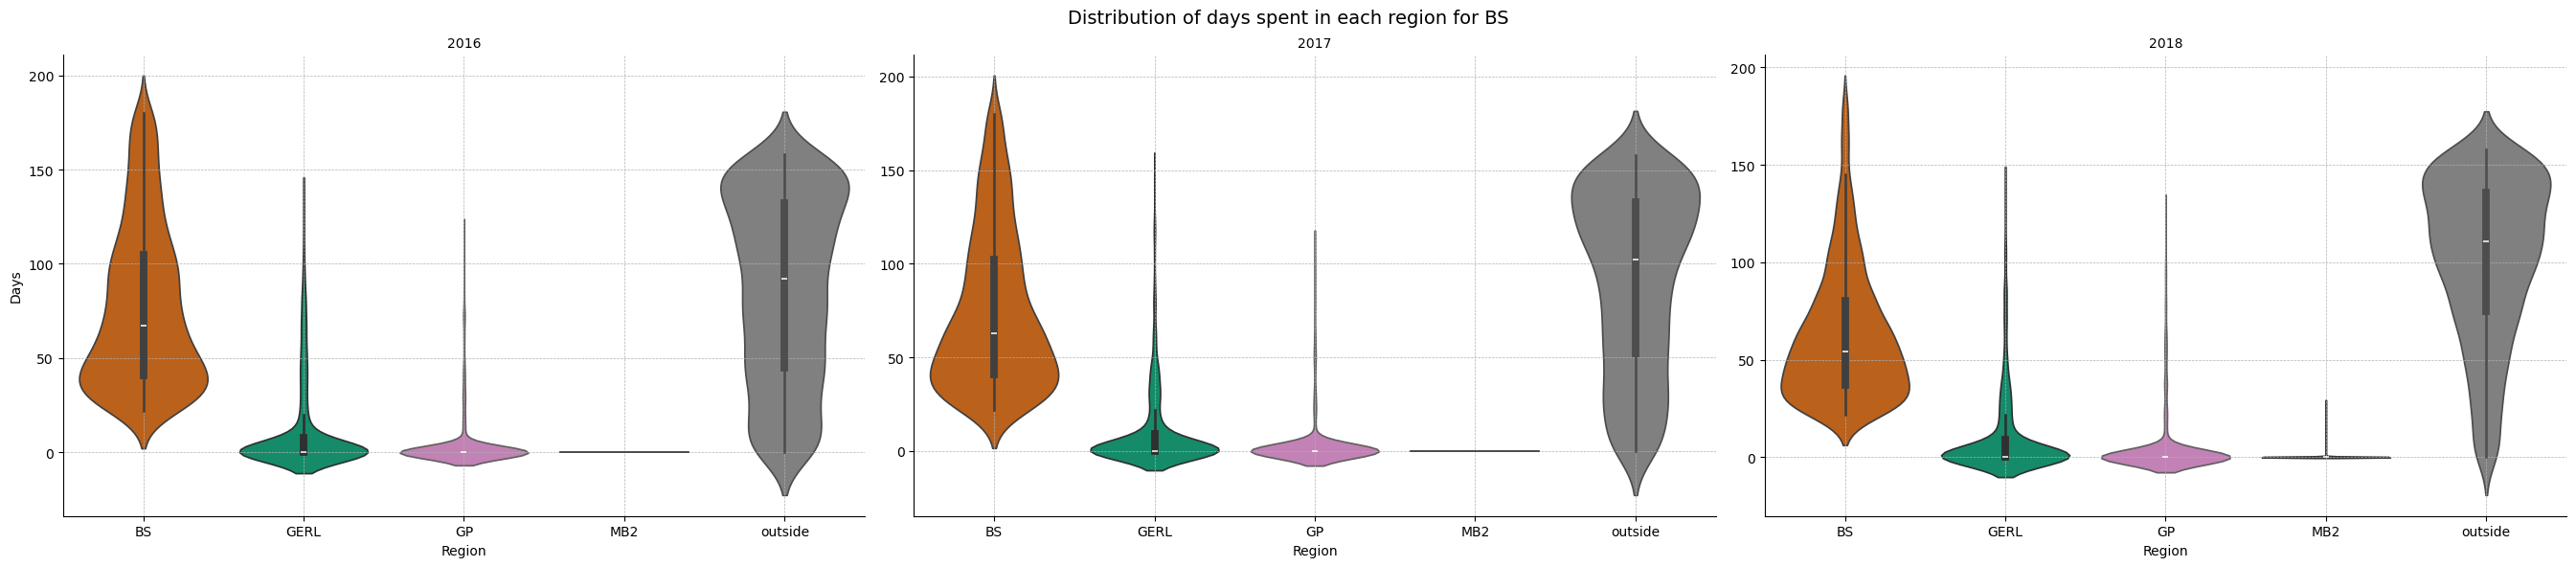

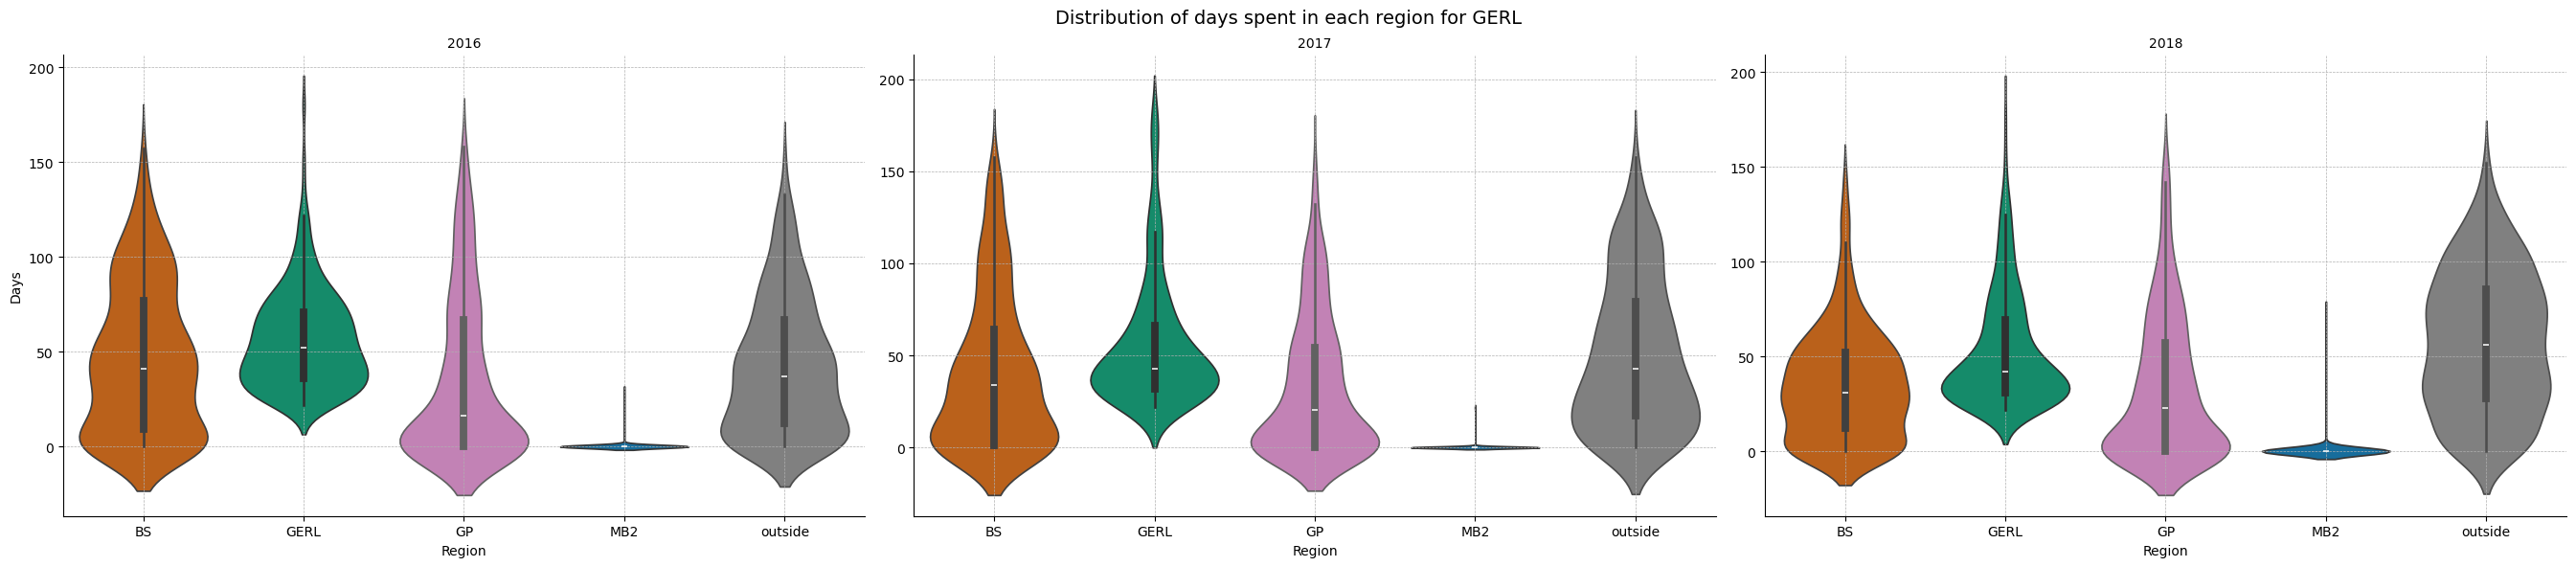

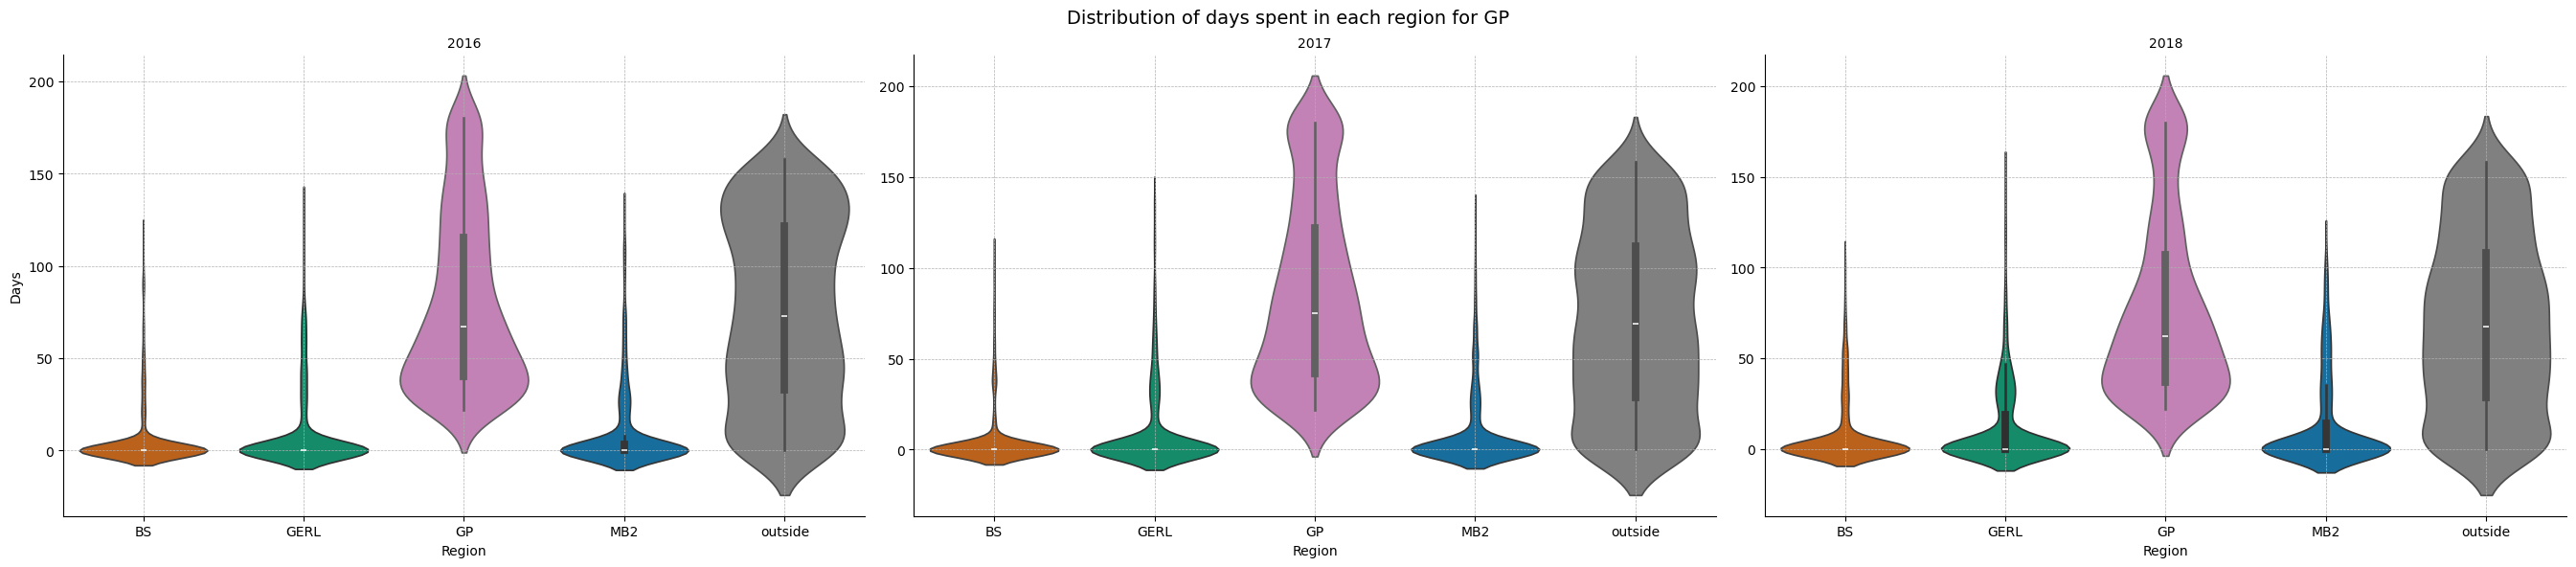

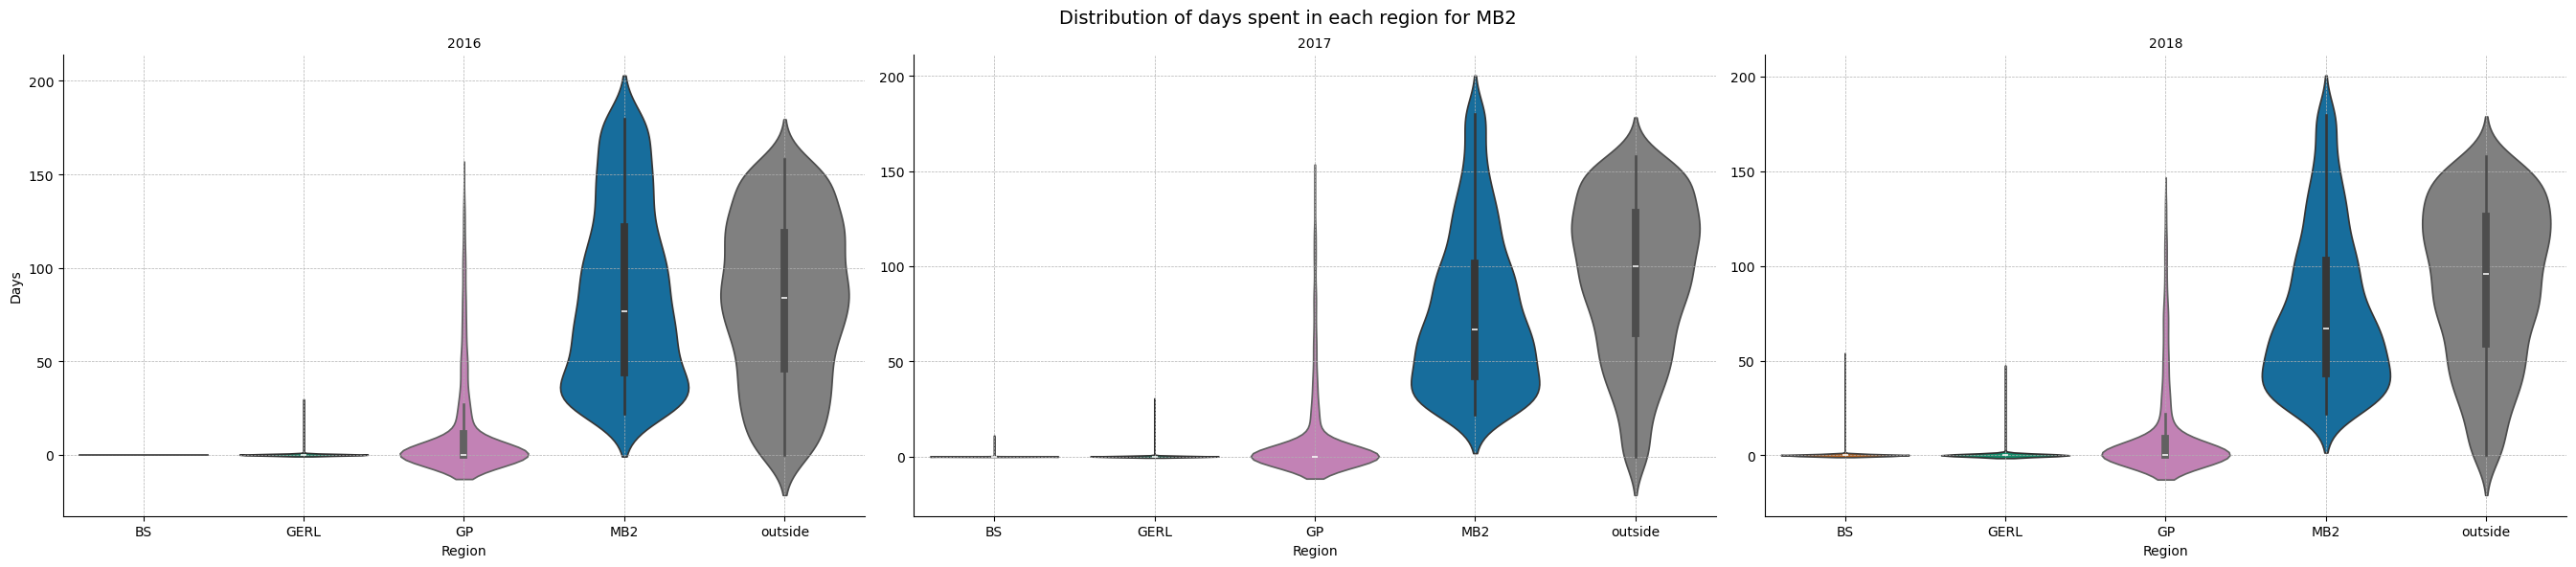

In [72]:
# List of locations
locations = ['BS', 'GERL', 'GP', 'MB2']

# Example hypotheses to plot
selected_hypotheses = ['h_null', 'h_ice', 'h_dvm', 'h_size']

# Loop through each location and generate the plot for the selected hypotheses
for loc in locations:
    plot_days_distribution_facet_yearly(df_retention, loc, selected_hypotheses, height=6, aspect=1.5)

# Stage Use

In [15]:
def summarize_presence_stage(df):
    presence_columns = ['BS', 'GERL', 'GP', 'MB2', 'outside']
    additional_columns = ['start_year', 'hypothesis', 'IDL_loc', 'stage']
    presence_summary = df.groupby(['larval_id'] + additional_columns)[presence_columns].sum().reset_index()
    return presence_summary
    
# Apply the summarize presence function by stage
df_retention_stage = summarize_presence_stage(df_traj)
df_retention_stage


,larval_id,start_year,hypothesis,IDL_loc,stage,BS,GERL,GP,MB2,outside
0,00_16_1_0003,2016,h_null,BS,0,6,0,0,0,0
1,00_16_1_0003,2016,h_null,BS,1,17,0,0,0,0
2,00_16_1_0003,2016,h_null,BS,2,38,0,0,0,0
3,00_16_1_0003,2016,h_null,BS,3,32,0,0,0,4
4,00_16_1_0003,2016,h_null,BS,4,0,0,0,0,83
...,...,...,...,...,...,...,...,...,...,...
57430,03_18_4_1075,2018,h_size,MB2,0,0,0,6,0,0
57431,03_18_4_1075,2018,h_size,MB2,1,0,0,17,0,0
57432,03_18_4_1075,2018,h_size,MB2,2,0,0,38,0,0
57433,03_18_4_1075,2018,h_size,MB2,3,0,0,14,0,22


In [16]:
def get_statistics_for_idl_loc(df, idl_loc):
    stats = []
    for hypothesis in df['hypothesis'].unique():
        for year in df['start_year'].unique():
            for stage in df['stage'].unique():
                filtered_df = df[(df['IDL_loc'] == idl_loc) & (df['start_year'] == year) & (df['hypothesis'] == hypothesis) & (df['stage'] == stage)]
                if not filtered_df.empty:
                    presence_column = idl_loc
                    outliers = ((filtered_df[presence_column] < filtered_df[presence_column].quantile(0.25)) |
                                (filtered_df[presence_column] > filtered_df[presence_column].quantile(0.75))).sum()
                    total_count = filtered_df[presence_column].count()
                    stats.append({
                        'year': year,
                        'hypothesis': hypothesis,
                        'stage': stage,
                        'mean': filtered_df[presence_column].mean(),
                        'median': filtered_df[presence_column].median(),
                        '1st_quartile': filtered_df[presence_column].quantile(0.25),
                        '3rd_quartile': filtered_df[presence_column].quantile(0.75),
                        'std': filtered_df[presence_column].std(),
                        'outliers': outliers,
                        'total': total_count
                    })
    if stats:
        return pd.DataFrame(stats)
    else:
        return None

# Custom order of hypotheses
hypothesis_order = ['Ocean', 'Ice', 'DVM', 'Size']
hypothesis_names = {'h_null': 'Ocean', 'h_ice': 'Ice', 'h_dvm': 'DVM', 'h_size': 'Size'}
location_names = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB2': 'M. Bay'}

# Dictionary to store DataFrames for each location
stats_tables = {}

# Loop through each location and store DataFrame in the dictionary
for specific_idl_loc, location_name in location_names.items():
    stats_table = get_statistics_for_idl_loc(df_retention_stage, specific_idl_loc)
    if stats_table is not None and not stats_table.empty:
        stats_table['hypothesis'] = stats_table['hypothesis'].map(hypothesis_names)
        stats_table['year'] = stats_table['year'].astype(int)
        stats_table['hypothesis'] = pd.Categorical(stats_table['hypothesis'], categories=hypothesis_order, ordered=True)
        stats_table = stats_table.sort_values(by=['year', 'hypothesis', 'stage'])
        
        # Store the DataFrame in the dictionary
        stats_tables[specific_idl_loc] = stats_table
        
        # # Print the DataFrame for the current location
        # print(f"Statistics for {location_name}")
        # print(stats_table)
        # print("\n")

In [29]:
# Function to preprocess the data and save it in a dictionary
def preprocess_data(df, location_names, hypothesis_names):
    processed_data = {}

    for location in location_names:
        for hypothesis in hypothesis_names:
            filtered_data = df[(df['IDL_loc'] == location) & (df['hypothesis'] == hypothesis)]
            if not filtered_data.empty:
                processed_data[(location, hypothesis)] = filtered_data.copy()
    
    return processed_data

# Example usage:
processed_data = preprocess_data(df_retention_stage, location_names, hypothesis_names)

# Print keys to verify the data
print(processed_data.keys())

dict_keys([('BS', 'h_null'), ('BS', 'h_ice'), ('BS', 'h_dvm'), ('BS', 'h_size'), ('GERL', 'h_null'), ('GERL', 'h_ice'), ('GERL', 'h_dvm'), ('GERL', 'h_size'), ('GP', 'h_null'), ('GP', 'h_ice'), ('GP', 'h_dvm'), ('GP', 'h_size'), ('MB2', 'h_null'), ('MB2', 'h_ice'), ('MB2', 'h_dvm'), ('MB2', 'h_size')])


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Custom colors for the stages
stage_colors = {
    0: '#efe7bc',  
    1: '#b4f8c8',  
    2: '#74bdcb',  
    3: '#3d5b59',  
    4: '#cb5b3b'  
}

# Stage names
stage_names = {
    0: 'Embryo (0-5d)',
    1: 'Nauplii (6-22d)',
    2: 'Calyptopes (23-60d)',
    3: 'Furcilia I-III (60-96d)',
    4: 'Furcilia IV+ (>96d)'
}

In [61]:
# Custom plotting function to add gridlines
def custom_violinplot(data, **kwargs):
    sns.violinplot(data=data, **kwargs, linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.7)

# Function to plot facet plots for each year for a given location and hypothesis
def plot_facet_plots(processed_data, location, hypothesis, stage_colors, stage_names):
    key = (location, hypothesis)
    if key not in processed_data:
        print(f"No data available for location: {location}, hypothesis: {hypothesis}")
        return
    
    data = processed_data[key]
    
    # Convert stage to categorical with the correct order
    data['stage'] = data['stage'].astype(int)
    data['stage'] = pd.Categorical(data['stage'], categories=stage_names.keys(), ordered=True)
    
    # Plotting
    g = sns.FacetGrid(data, col="start_year", hue="stage", palette=stage_colors, col_wrap=3, height=4, aspect=1.75, sharey=False)
    g.map_dataframe(custom_violinplot, x='stage', y=location, order=stage_names.keys(), cut=0)
    
    g.set_axis_labels("Stage", "Time Spent (days)")
    g.despine(left=True)
    g.tight_layout()
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle(f'Duration in {location_names[location]} ({hypothesis_names[hypothesis]} Simulation)', fontsize=14)
    
    # Save and show the plot
    plt.savefig(f"{fig_path}facet_time_spent_{location.lower()}_{hypothesis.lower()}.png")
    plt.show()


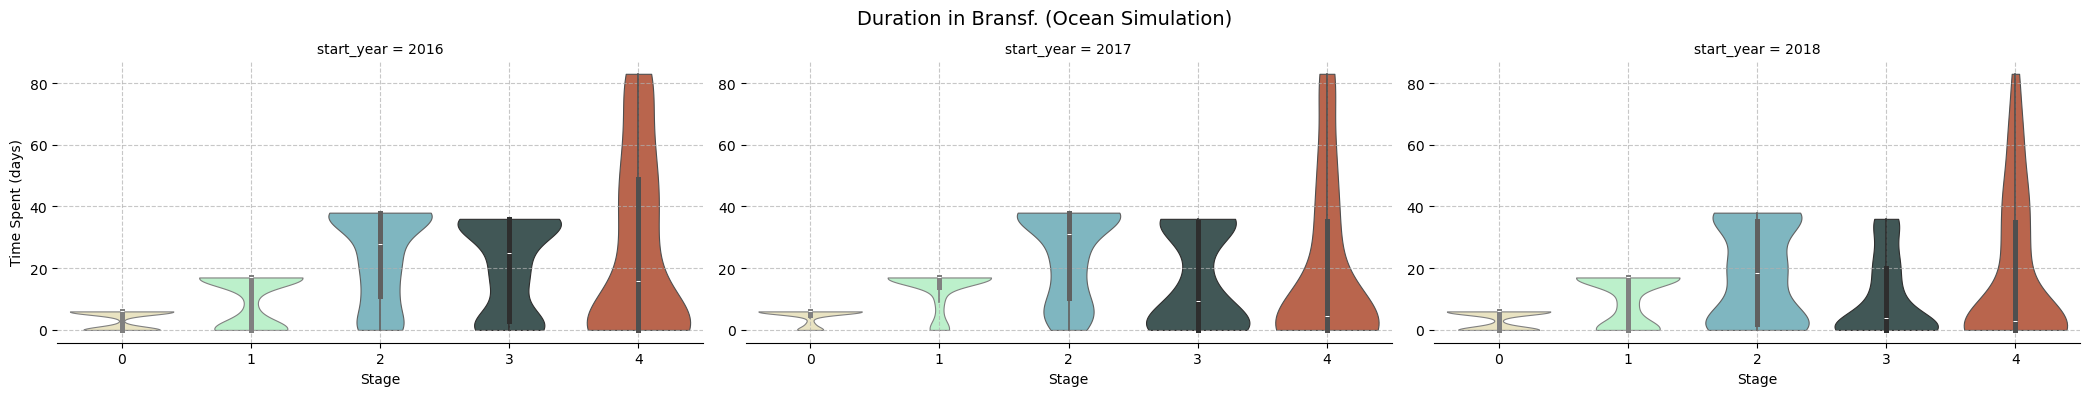

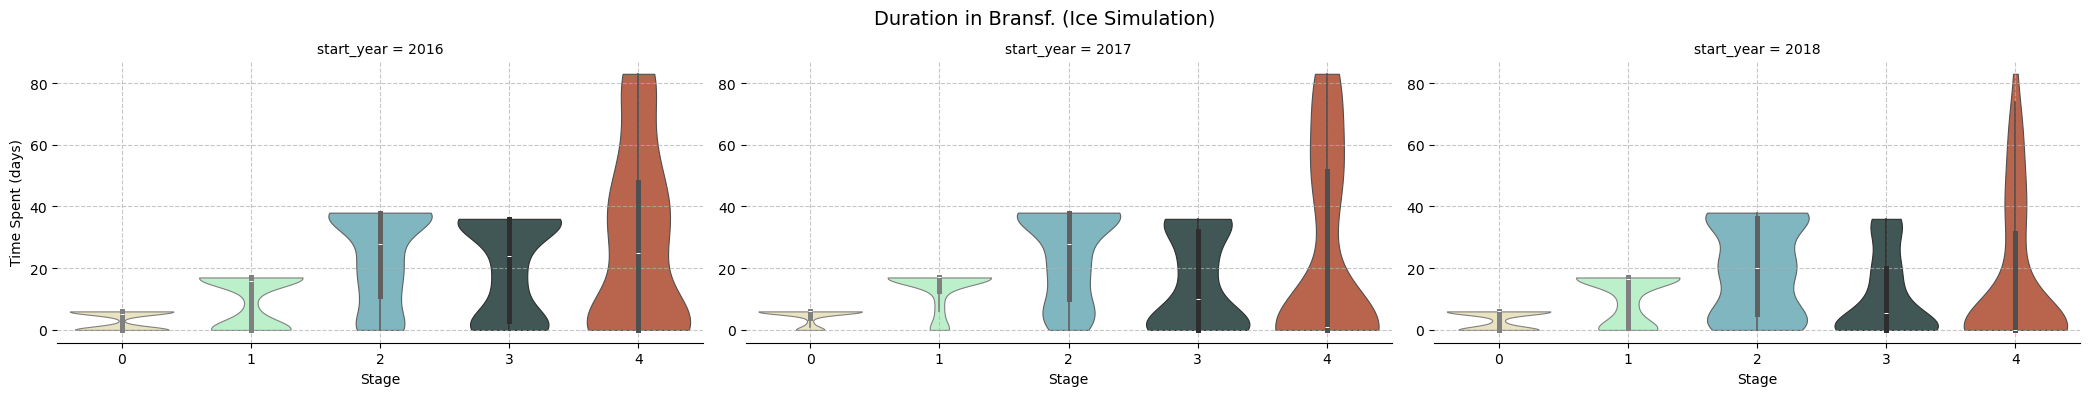

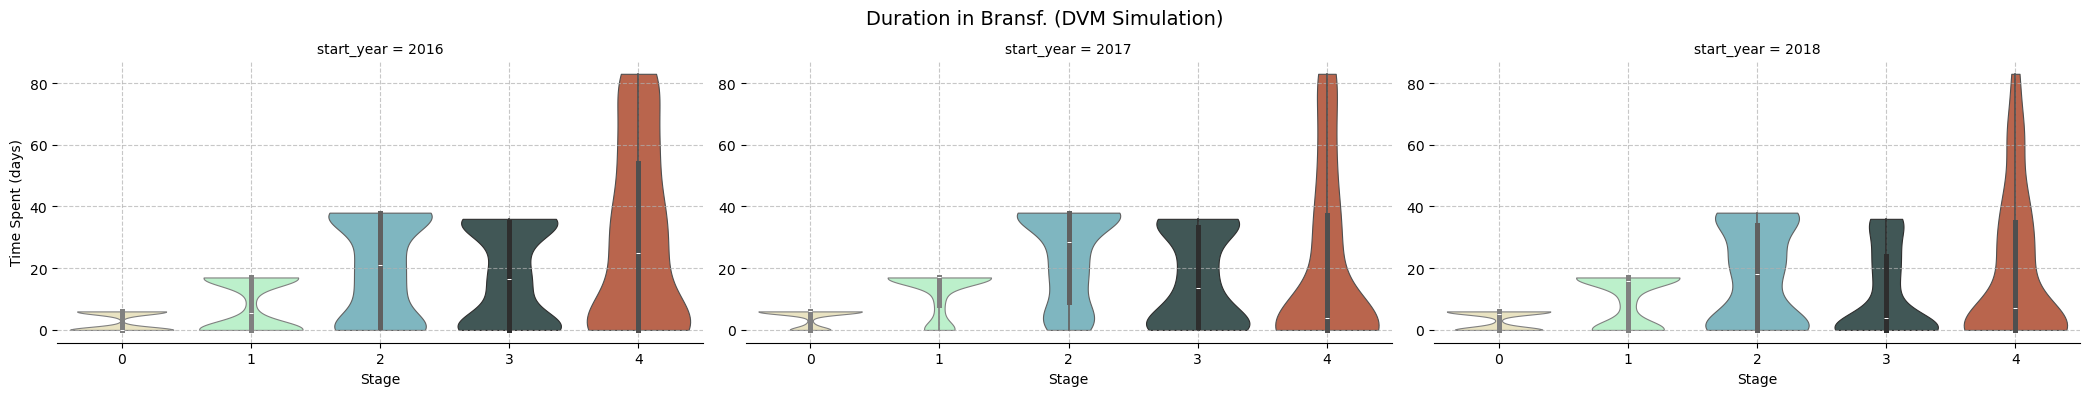

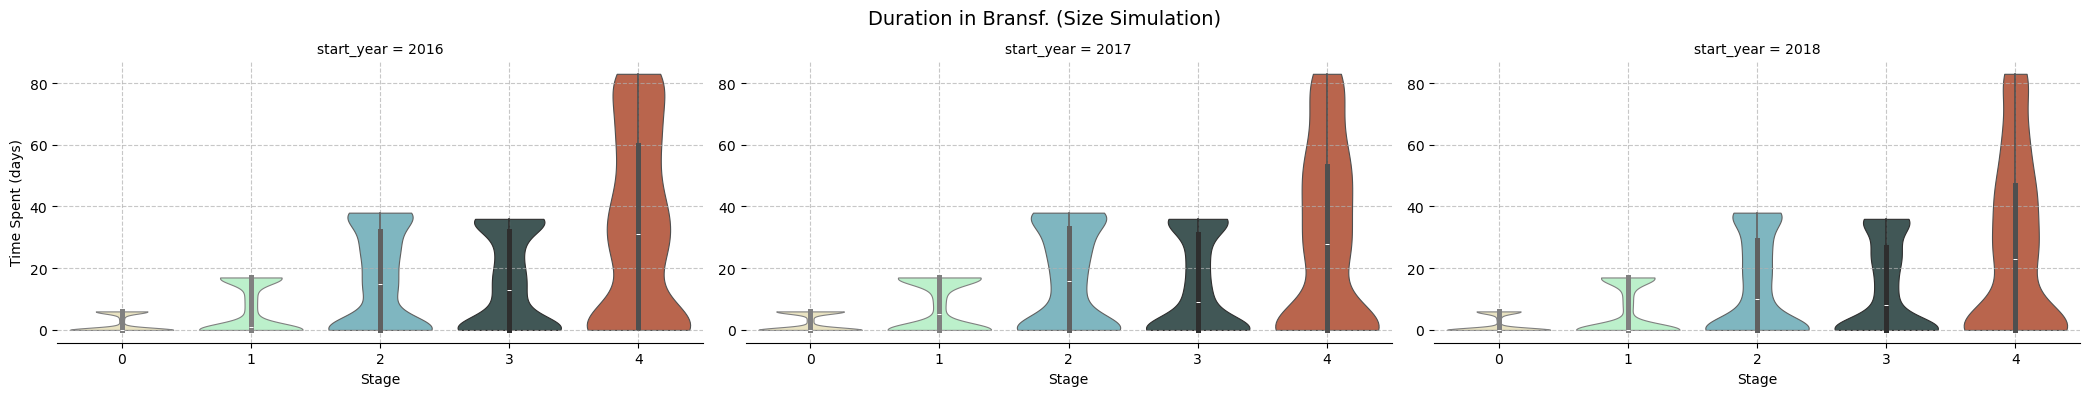

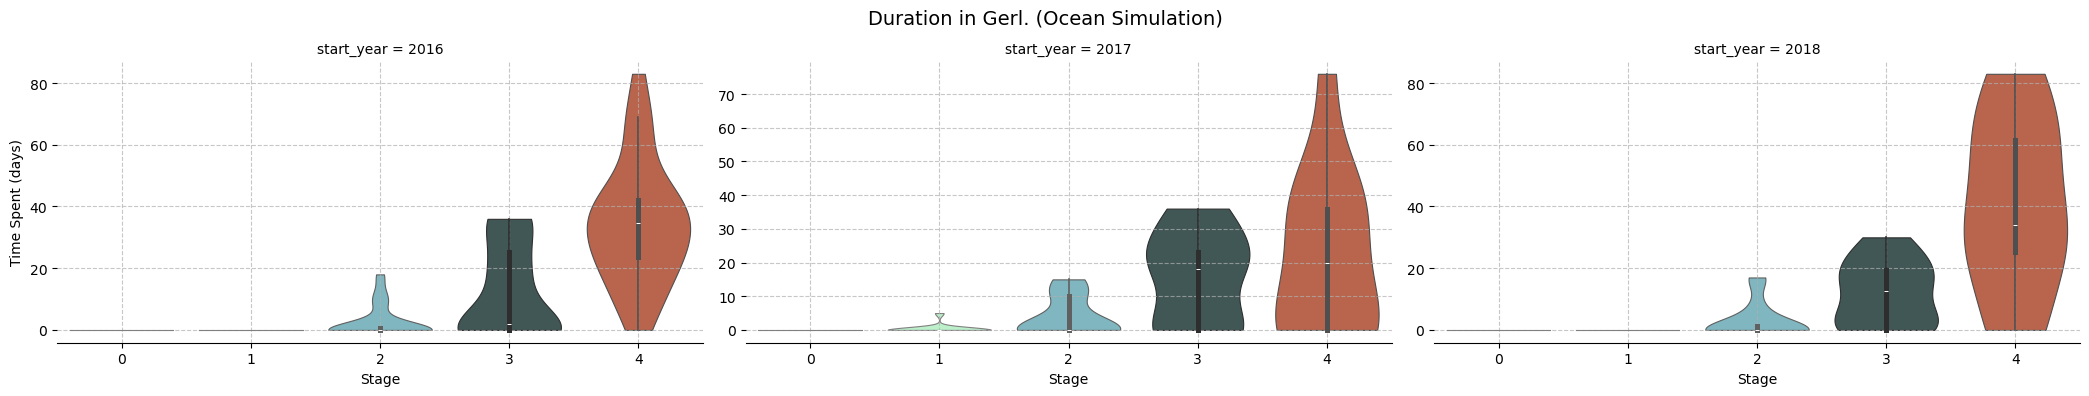

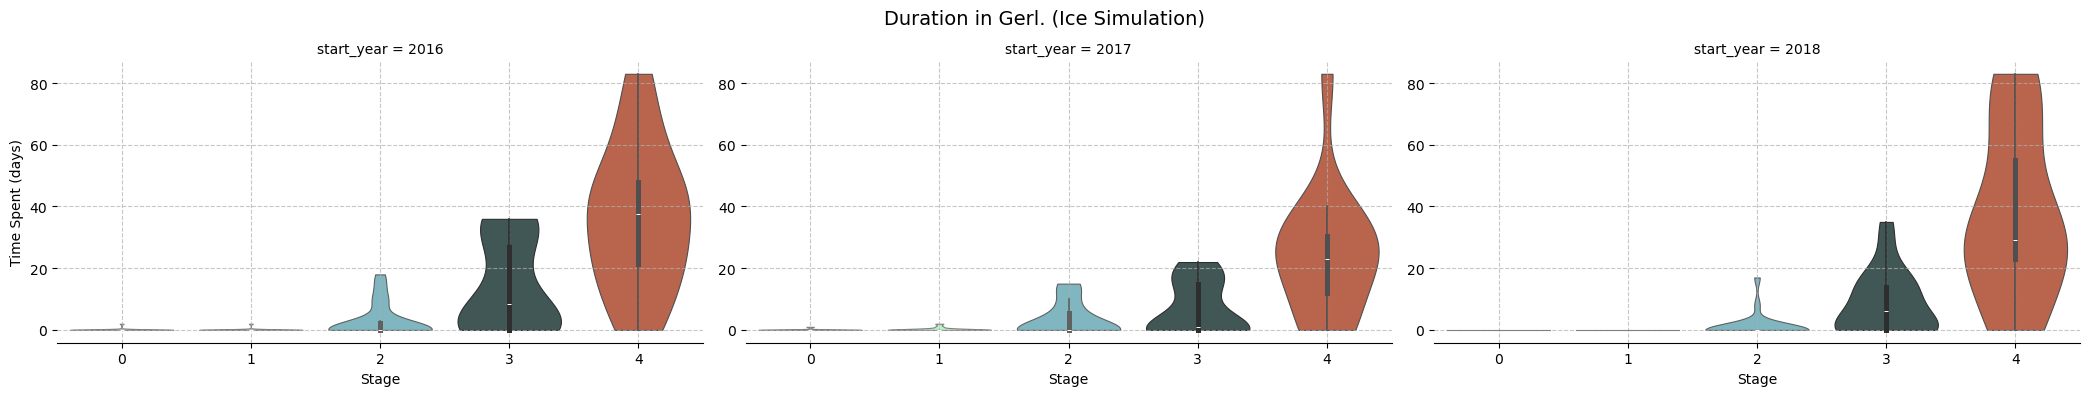

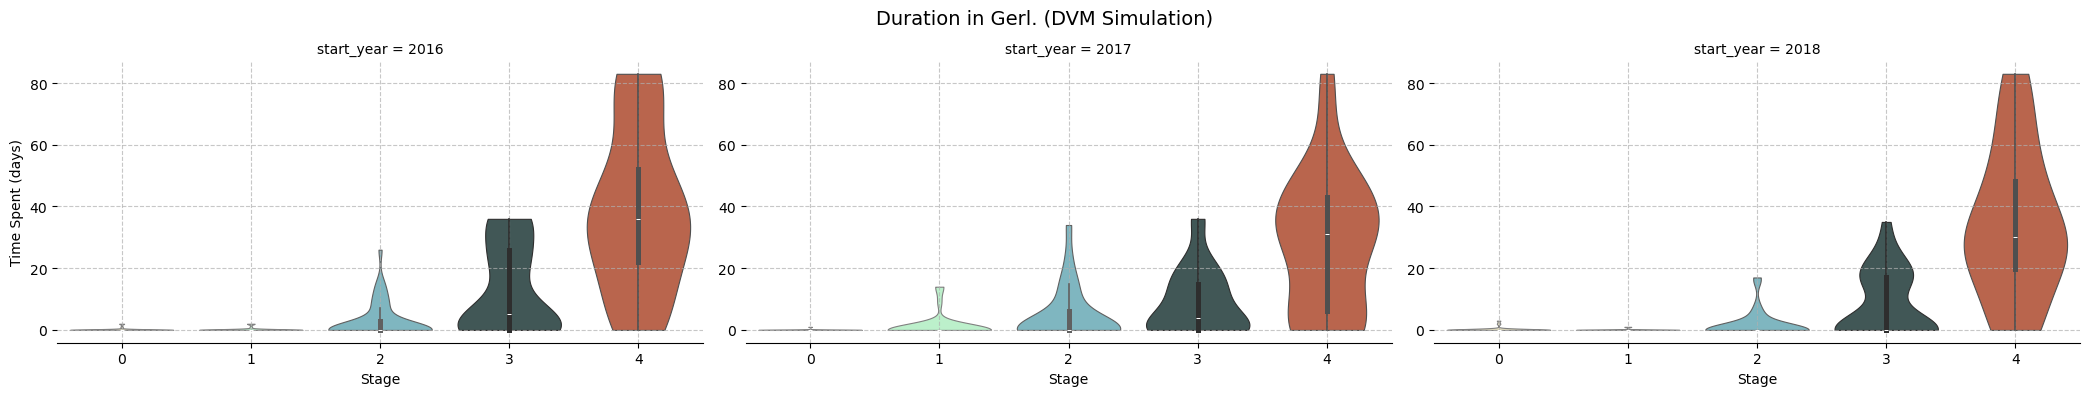

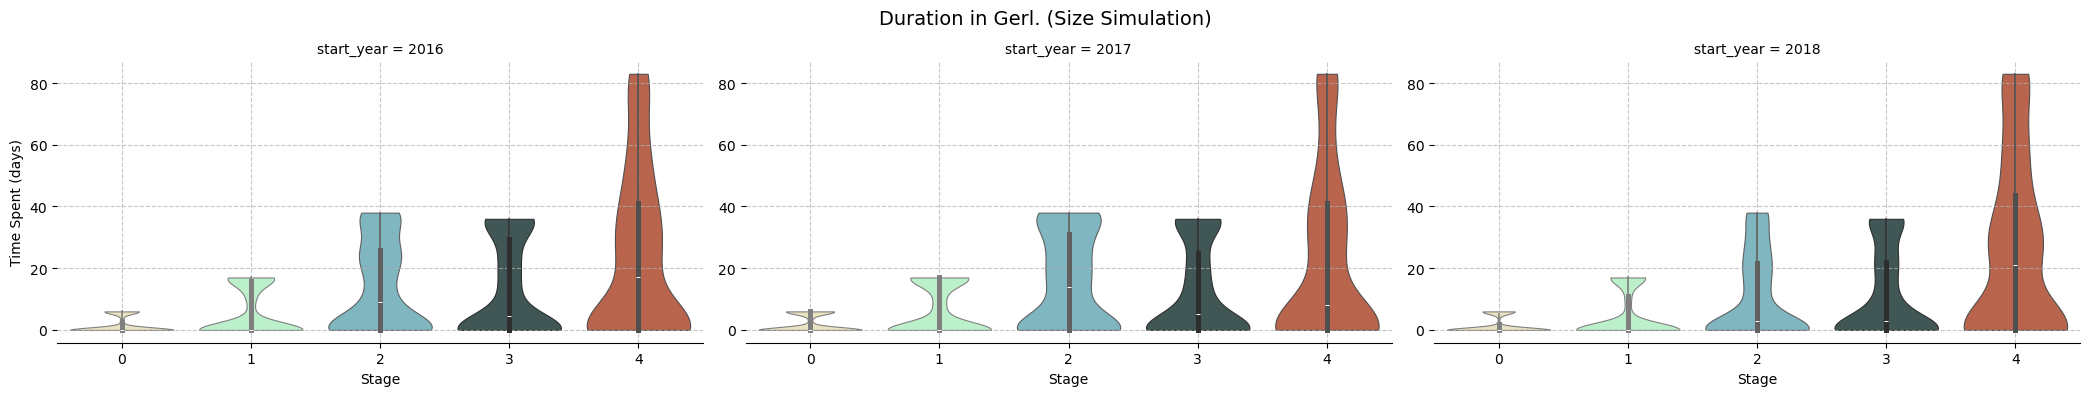

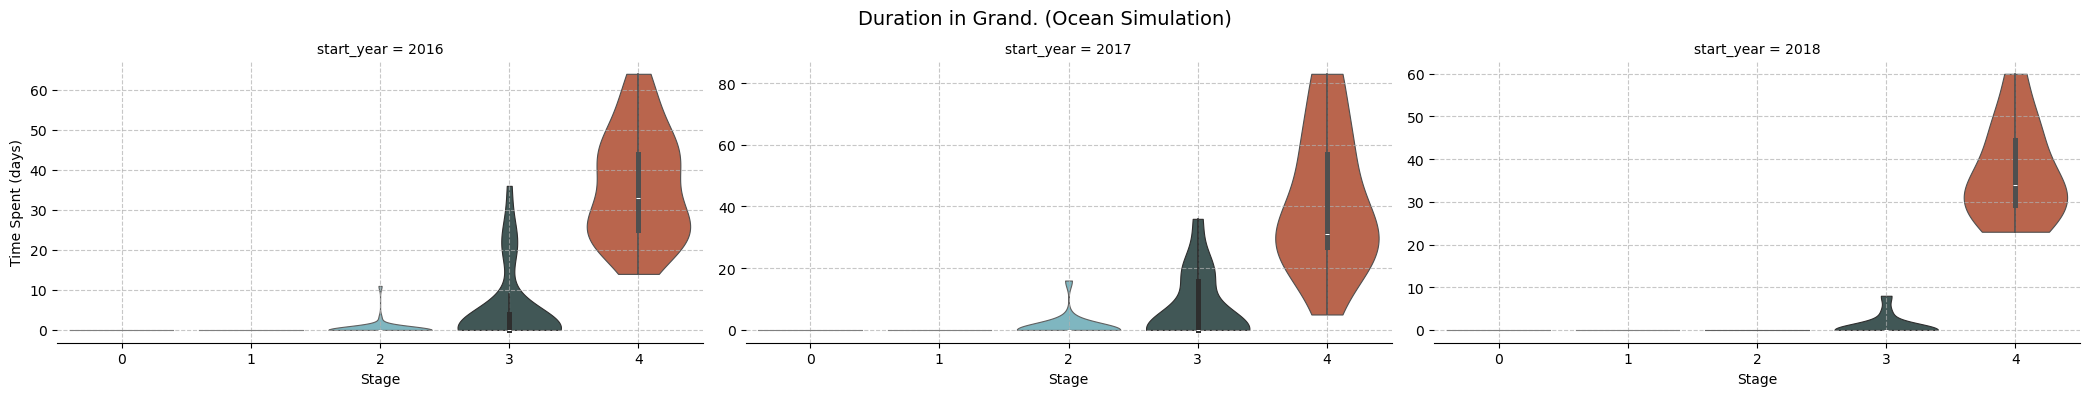

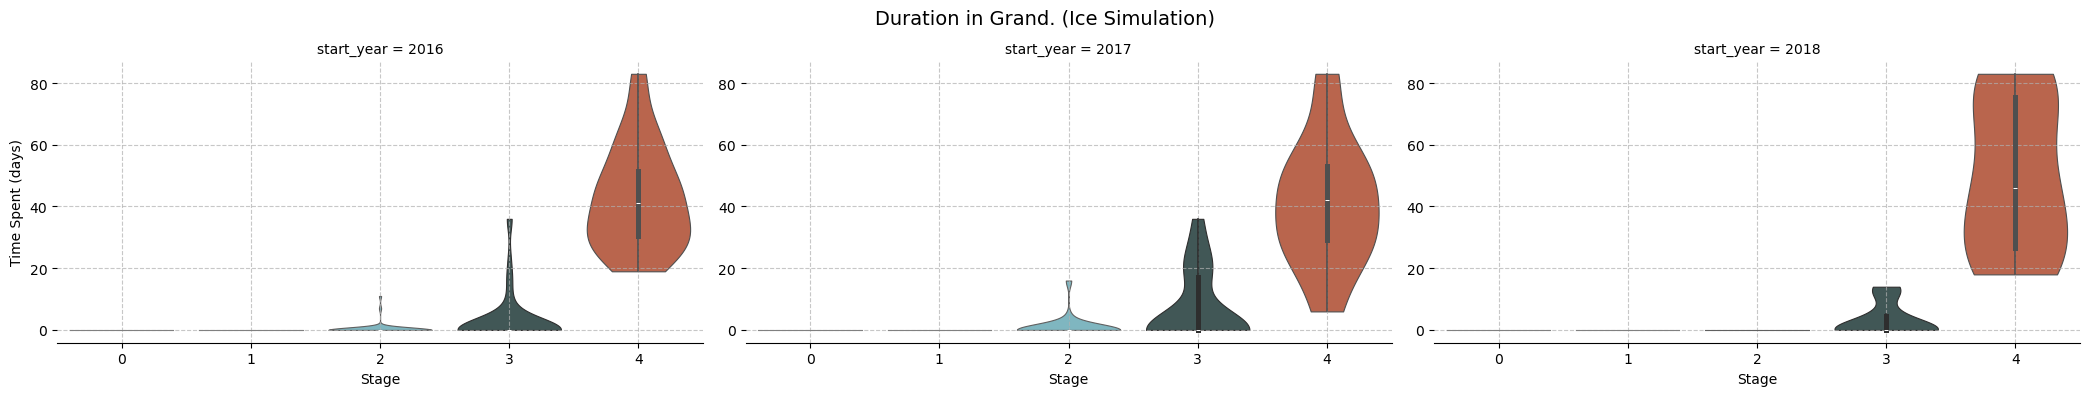

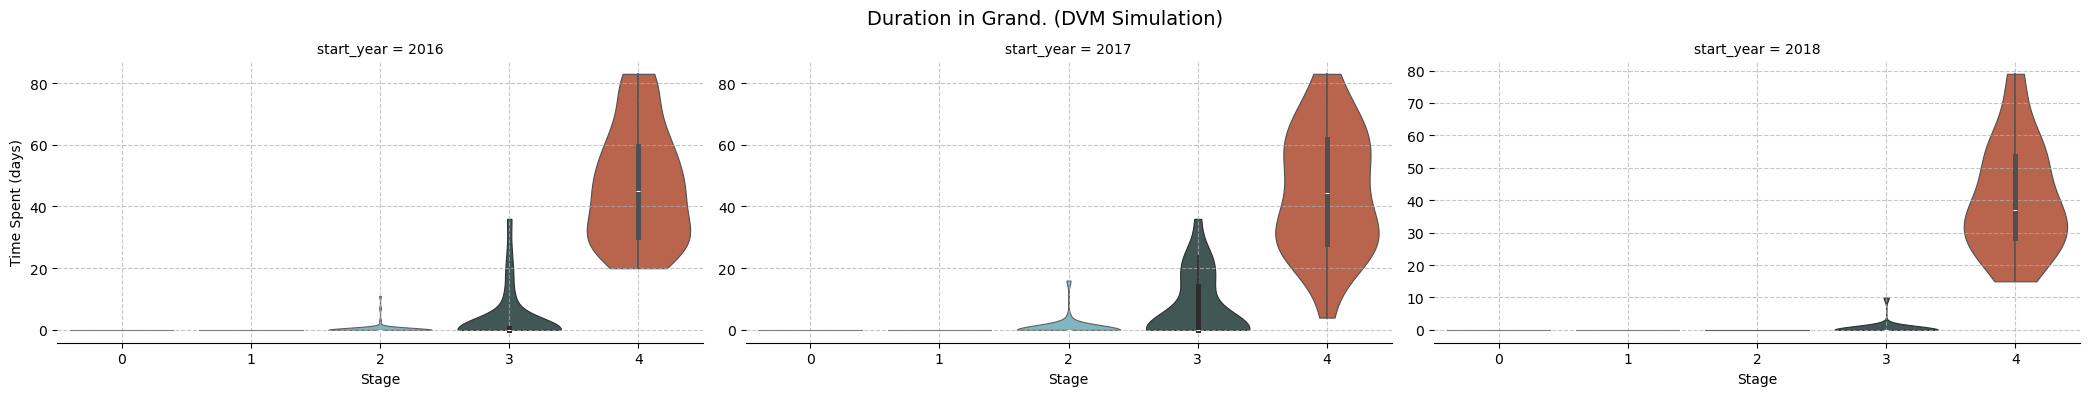

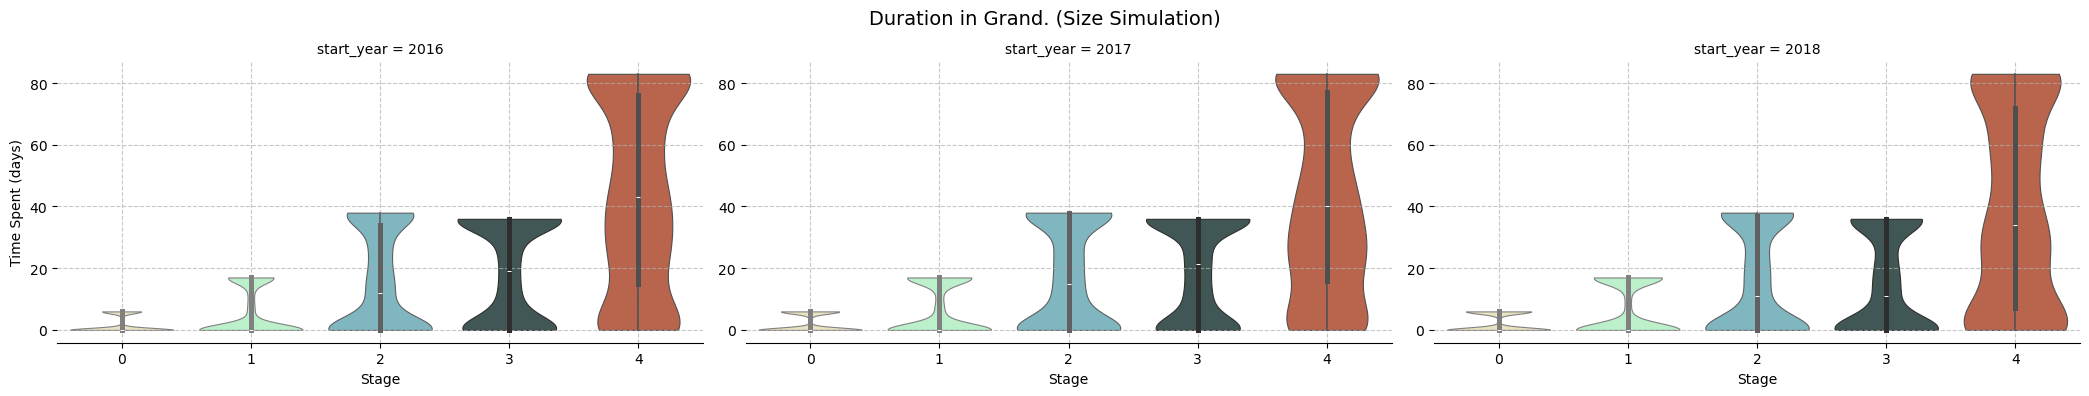

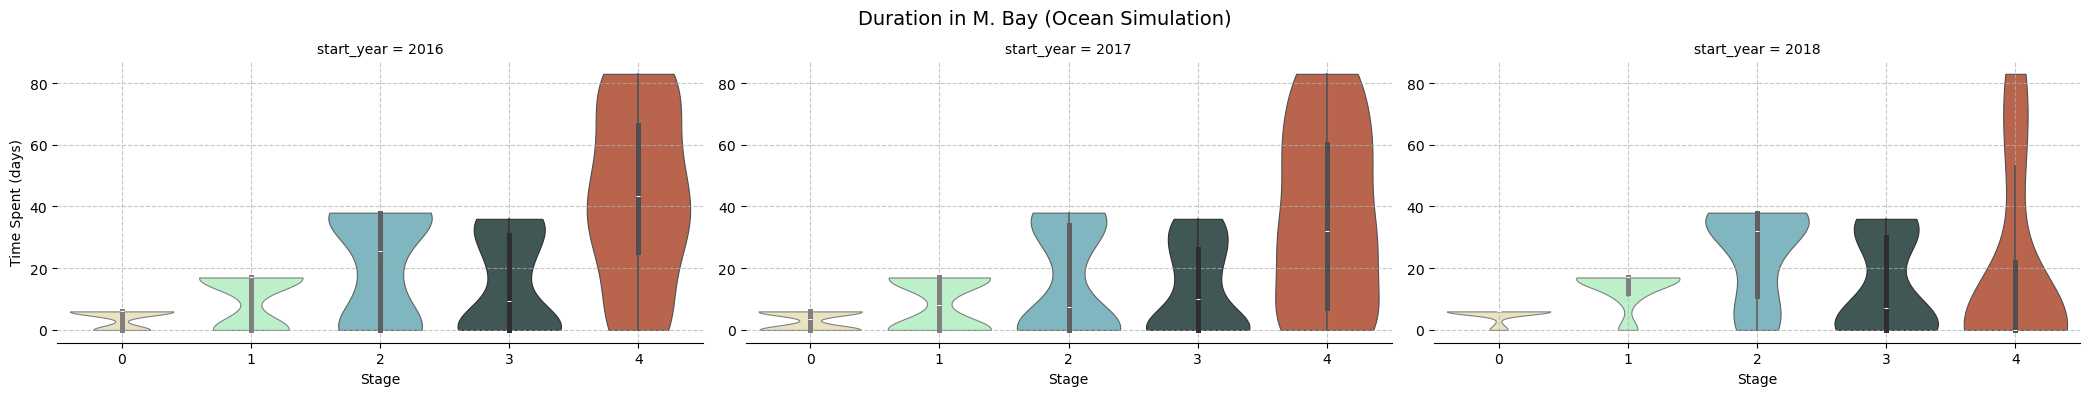

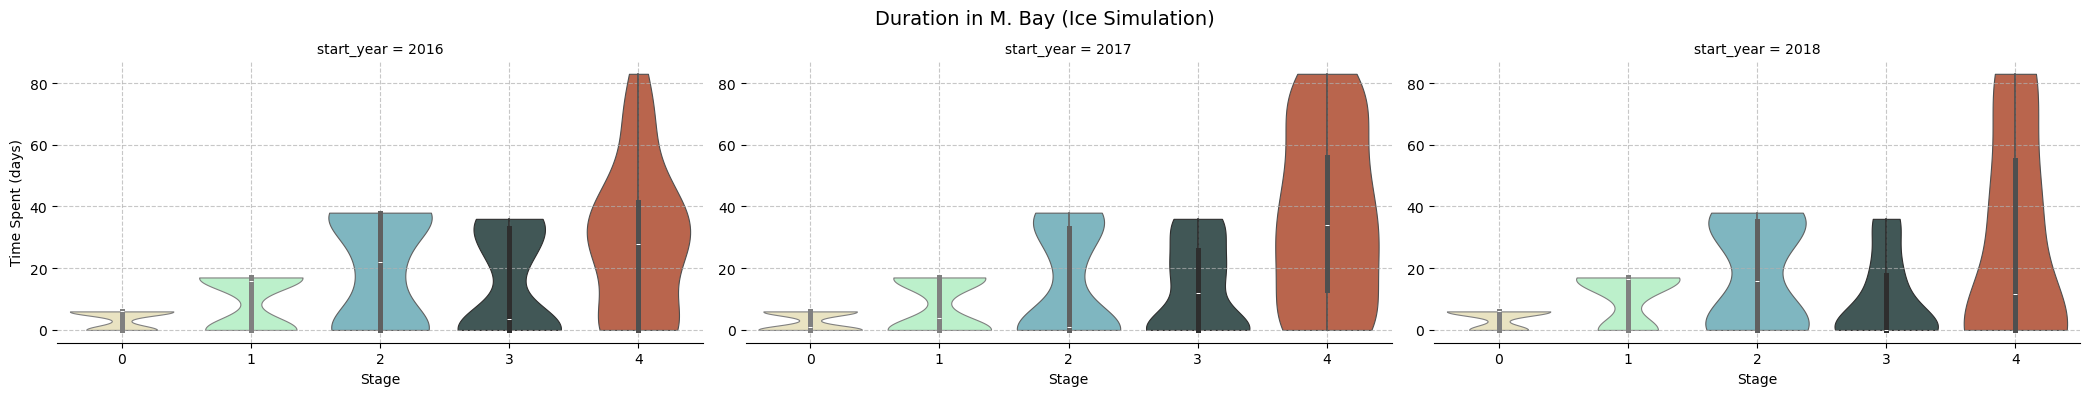

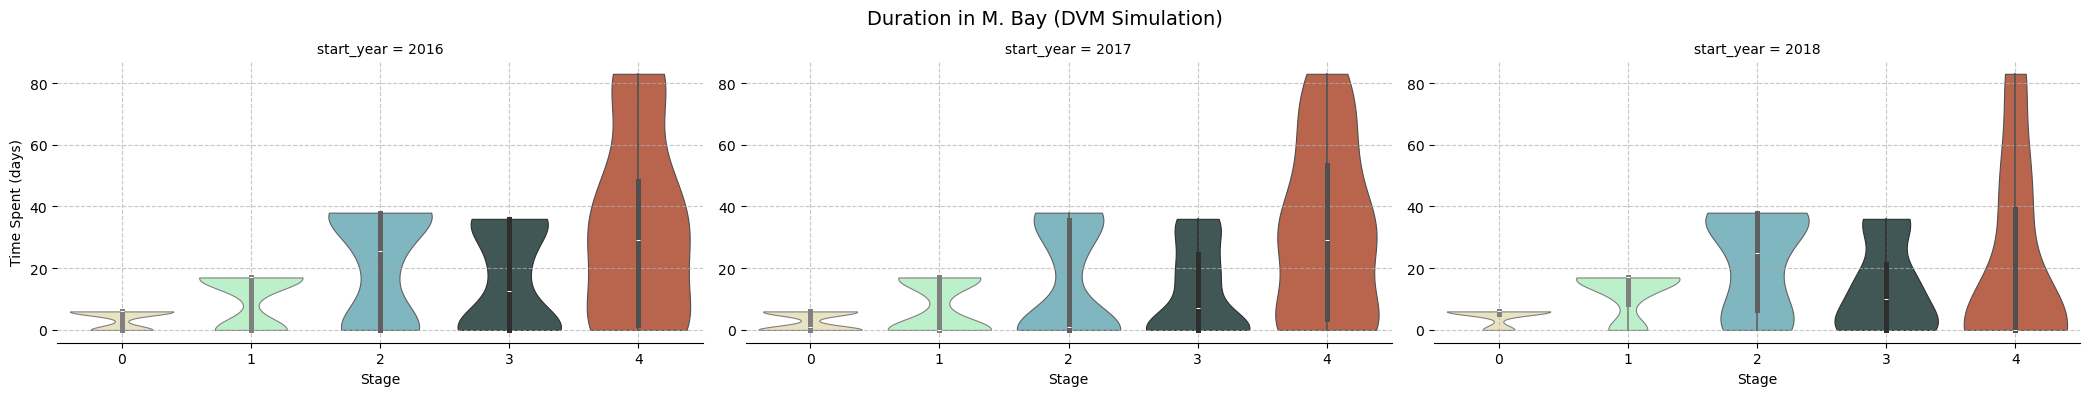

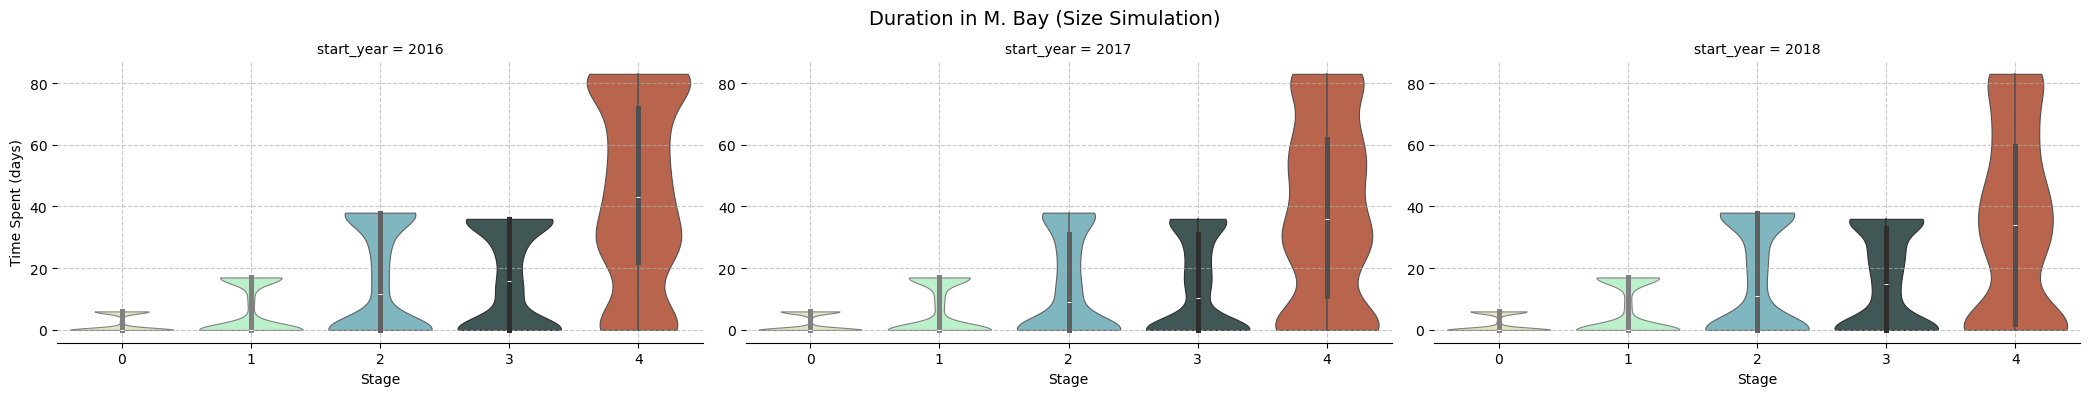

In [63]:

# Loop over each location and hypothesis
for location in location_names.keys():
    for hypothesis in hypothesis_names.keys():
        plot_facet_plots(processed_data, location, hypothesis, stage_colors, stage_names)